# Model Analysis — Logistic Regression

This notebook develops and compares logistic regression models to predict customer response to a monthly food basket subscription campaign for a retail food company. Building on the EDA, which identified behavioural variables, particularly past campaign acceptance and recency, as the strongest predictors of response, the modelling strategy follows a structured diagnostic logic:

1. A **Full Model** trained on all engineered features to identify which predictors survive penalisation.
2. A **Behavioural Model** focusing on engagement and purchase history.
3. A **Demographic Model** focusing on customer profile and household composition.

Comparing these three models allows us to assess whether campaign response is better explained by *who the customer is* or *how the customer behaves*, and to select the most actionable model for deployment.

## 0. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from scipy.stats import loguniform

import warnings
warnings.filterwarnings('ignore')

# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# OOF threshold tuning helper
def find_best_threshold_oof(pipeline, X_train, y_train, cv=5):
    oof_probs = cross_val_predict(
        pipeline, X_train, y_train, cv=cv, method="predict_proba"
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"Optimal threshold (F1): {best_threshold:.4f}")
    print(f"Best OOF F1:            {best_f1:.4f}")

    return best_threshold

#Standardised evaluation helper
def evaluate_model(model, X_te, y_te, model_name, threshold=0.5):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model':     model_name,
        'Threshold': round(threshold, 4),
        'ROC-AUC':   round(roc_auc_score(y_te, y_prob), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1':        round(f1_score(y_te, y_pred, zero_division=0), 4),
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
    }

In [3]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"Dataset shape: {df.shape}")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns

Dataset shape: (2236, 30)

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

The clean dataset already includes the engineered features from the EDA notebook
(`Total_Spending`, `Total_Purchases`, `Total_Accepted_Campaigns`, `Customer_Tenure`, `Age`).

The original columns (individual spend categories and individual campaign dummies) are
dropped here, as they have been combined into the aggregated features. `Income_missing` and
`Complain` are also dropped.

To enable clean model comparisons, three non-overlapping feature sets are constructed upfront and in the following section.

In [4]:
# Create copy of the dataframe for modeling
df_model = df.copy()

# Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]

df_model = df_model.drop(columns=cols_to_drop)


# Define features and target
target = 'Response'

## Full Model
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

## Behavioural Model
numerical_features_behav = [
    'Recency', 'Total_Spending', 'Total_Purchases',
    'Total_Accepted_Campaigns', 'NumDealsPurchases', 'NumWebVisitsMonth'
]
categorical_features_behav = [] 

# Demographic Model
numerical_features_demo = [
    'Age', 'Income', 'Customer_Tenure',
    'Kidhome', 'Teenhome'
]
categorical_features_demo = ['Education', 'Marital_Status']


print(f"Full model: {len(numerical_features_full)} numerical + {len(categorical_features_full)} categorical")
print(f"Behavioural: {len(numerical_features_behav)} numerical + {len(categorical_features_behav)} categorical")
print(f"Demographic: {len(numerical_features_demo)} numerical + {len(categorical_features_demo)} categorical")

Full model: 11 numerical + 2 categorical
Behavioural: 6 numerical + 0 categorical
Demographic: 5 numerical + 2 categorical


## 2. Train/Test Split

The train and test indices were created once in the EDA notebook (Section 9) using a stratified 80/20 split with `random_state=42`, and saved to disk as `.npy` files.

Loading them here, rather than calling `train_test_split` again, guarantees that this notebook uses exactly the same observations as the advanced models developed in this project, making cross-model comparisons statistically valid.

In [5]:
X_all = df_model[numerical_features_full + categorical_features_full]
y = df_model[target].copy()

# Load the shared split indices produced in EDA.ipynb (Section 9)
idx_train = np.load('../data/idx_train.npy')
idx_test  = np.load('../data/idx_test.npy')

# Slice each feature matrix and the target using the shared indices
X_train_all = X_all.iloc[idx_train]
X_test_all  = X_all.iloc[idx_test]
y_train = y.iloc[idx_train]
y_test = y.iloc[idx_test]

X_train_full  = X_train_all[numerical_features_full + categorical_features_full]
X_test_full   = X_test_all[numerical_features_full + categorical_features_full]

X_train_behav = X_train_all[numerical_features_behav]
X_test_behav  = X_test_all[numerical_features_behav]

X_train_demo = X_train_all[numerical_features_demo + categorical_features_demo]
X_test_demo  = X_test_all[numerical_features_demo + categorical_features_demo]

print(f'Train size: {len(y_train):,}  (positives: {y_train.sum()})')
print(f'Test size:  {len(y_test):,}   (positives: {y_test.sum()})')
print(f'Train positive rate: {y_train.mean():.1%}')
print(f'Test  positive rate: {y_test.mean():.1%}')


Train size: 1,788  (positives: 267)
Test size:  448   (positives: 67)
Train positive rate: 14.9%
Test  positive rate: 15.0%


**Class Imbalance and Evaluation Strategy**
The target variable is imbalanced, with only a relatively small share of customers responding positively to the campaign. 

For this project, identifying actual responders is the key business objective, so Precision, Recall, F1, Precision-Recall curves, and threshold selection (in addition to ROC-AUC) are also required to evaluate whether the model is operationally useful.

In [6]:
positive_rate = df['Response'].mean()
negative_rate = 1 - positive_rate

print(f"Positive class rate: {positive_rate:.2%}")
print(f"Negative class rate: {negative_rate:.2%}")
print(f"Class ratio (No Response : Response) = {negative_rate/positive_rate:.2f} : 1")


Positive class rate: 14.94%
Negative class rate: 85.06%
Class ratio (No Response : Response) = 5.69 : 1


## 3. Full Model - Elastic Net Regularisation

The full model uses **Elastic Net** regularisation, which combines L1 and L2 penalties through the `l1_ratio` parameter. This is well suited to the full feature set, where some engineered predictors may contain overlapping information.

The choice of Elastic Net over pure L1 or L2 is not assumed a priori, but validated empirically in Section 3.2 through a cross-validated comparison of alternative regularisation strategies at a fixed `C = 1.0`.

### 3.1. Baseline Model (No Tuning)

Before introducing more advanced modelling choices, a baseline Logistic Regression model is estimated using scikit-learn’s default specification for the penalty structure (`L2`, `C = 1.0`, `lbfgs` solver), while retaining `class_weight='balanced'` to account for the imbalanced response variable.

The model is evaluated using 5-fold cross-validation on the training set only. This provides a reference level of predictive performance against which later decisions — such as alternative regularisation strategies and hyperparameter tuning — can be assessed.

At this stage, the goal is not to optimise the model, but to establish a robust benchmark for discrimination (`ROC-AUC`) and positive-class performance (`Recall` and `F1`).

In [7]:
# Helper to create a fresh preprocessor for each model (to avoid data leakage from fitting on the full training set)
def make_preprocessor_full():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features_full)
    ])

# Baseline with sklearn defaults (L2, C=1.0, lbfgs)
full_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_full()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])
baseline_auc_full = cross_val_score(
    full_model_base,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

baseline_f1_full = cross_val_score(
    full_model_base,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='f1'
)

baseline_recall_full = cross_val_score(
    full_model_base,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='recall'
)

print("Baseline Logistic Regression — Full Model (training CV only)")
print(f"ROC-AUC : {baseline_auc_full.mean():.4f} ± {baseline_auc_full.std():.4f}")
print(f"Recall  : {baseline_recall_full.mean():.4f} ± {baseline_recall_full.std():.4f}")
print(f"F1      : {baseline_f1_full.mean():.4f} ± {baseline_f1_full.std():.4f}")

Baseline Logistic Regression — Full Model (training CV only)
ROC-AUC : 0.8881 ± 0.0207
Recall  : 0.8089 ± 0.0386
F1      : 0.5602 ± 0.0362


The baseline model already shows strong discriminatory power, achieving a cross-validated ROC-AUC of 0.8881. It also delivers high recall on the positive class (0.8089), indicating that it captures a large share of potential responders, although with a more moderate F1 score (0.5602), reflecting the trade-off between recall and precision.

These results suggest that the available features contain substantial predictive signal, while still leaving room to test whether alternative regularisation strategies can improve model stability or interpretability.

### 3.2. Regularisation Strategy Selection

The full model includes a relatively large set of features, some of which may capture overlapping information. In this context, regularisation is important to control model complexity, reduce overfitting, and improve coefficient stability.

To determine the appropriate level of regularisation, four logistic regression specifications were compared on the training set using 5-fold stratified cross-validation: no regularisation, L2, L1, and Elastic Net.

All models were evaluated at a fixed regularisation strength (`C = 1.0`) to isolate the effect of the penalty type.

The comparison was based on ROC-AUC, as the objective at this stage is to assess each model’s ability to discriminate between responders and non-responders independently of any classification threshold.

In [8]:
# Compare regularisation strategies
from sklearn.model_selection import cross_val_score

reg_configs = [
    {
        'name':    'No Regularisation',
        'penalty': None,
        'solver':  'lbfgs',
        'C':       1.0,      
        'l1_ratio': None,
    },
    {
        'name':    'L2 (Ridge)',
        'penalty': 'l2',
        'solver':  'lbfgs',
        'C':       1.0,
        'l1_ratio': None,
    },
    {
        'name':    'L1 (Lasso)',
        'penalty': 'l1',
        'solver':  'saga',
        'C':       1.0,
        'l1_ratio': None,
    },
    {
        'name':    'Elastic Net',
        'penalty': 'elasticnet',
        'solver':  'saga',
        'C':       1.0,
        'l1_ratio': 0.5,
    },
]

reg_results = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_full, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df = pd.DataFrame(reg_results).set_index('Regularisation')
print("Regularisation Strategy Comparison (C=1.0, untuned)\n")
print(reg_df.to_string())

Regularisation Strategy Comparison (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.8816      0.0150
L2 (Ridge)              0.8881      0.0207
L1 (Lasso)              0.8880      0.0209
Elastic Net             0.8882      0.0207


The results show that all three regularised models perform very similarly, with cross-validated ROC-AUC values close to 0.888, while the unregularised specification performs slightly worse. This indicates that some degree of regularisation is beneficial for this feature set.

Among the regularised alternatives, **Elastic Net** achieves the highest average ROC-AUC, although the difference relative to L1 and L2 is small.

Elastic Net is therefore retained as the preferred regularisation strategy. In addition to its marginal performance advantage, it provides a useful compromise between L1 and L2 penalties, combining coefficient shrinkage with selective feature reduction, which is particularly valuable given the presence of correlated predictors in the full model.

While Elastic Net slightly outperforms the alternatives, the differences are small. This suggests that model performance is relatively stable across regularisation choices, but also raises the question of whether further gains can be achieved by optimising the strength and balance of the penalty.

### 3.3 Hyperparameter Tuning (RandomizedSearchCV + GridSearchCV)


After selecting **Elastic Net** as the preferred regularisation strategy, the next step is to assess whether its performance can be improved by optimising its key hyperparameters: the regularisation strength (`C`) and the balance between L1 and L2 penalties (`l1_ratio`).

Although the previous section showed that model performance is relatively stable across regularisation types, tuning allows us to verify whether a more precise configuration can deliver incremental gains.

To balance efficiency and precision, tuning is carried out in two stages.

The search is carried out in two stages:

- **Stage 1 — RandomizedSearchCV**: explores a broad range of values for `C` (sampled from a log-uniform distribution between 0.001 and 10) and five candidate values for `l1_ratio` (0.1, 0.3, 0.5, 0.7, 0.9), identifying the most promising region of the parameter space without exhaustively evaluating all combinations.

- **Stage 2 — GridSearchCV**: performs a narrower search around the best `C` found in Stage 1, keeping `l1_ratio` fixed at its optimal value. This refines the regularisation strength in the region where the model already performs well.

This two-stage approach balances search efficiency with precision, reducing the risk of missing a good solution while avoiding the computational cost of a full grid search over the entire parameter space.

In [9]:
# Broad randomized search
param_dist = {
    'classifier__C': loguniform(1e-3, 10),
    'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

rand_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_distributions=param_dist,
    n_iter=30,
    cv=cv_strategy,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1,
    verbose=1
)

rand_search.fit(X_train_full, y_train)

best_C_rand = rand_search.best_params_['classifier__C']
best_l1_rand = rand_search.best_params_['classifier__l1_ratio']

print("Stage 1 — RandomizedSearchCV")
print(f"Best parameters: {rand_search.best_params_}")
print(f"Best CV AUC:    {rand_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Stage 1 — RandomizedSearchCV
Best parameters: {'classifier__C': np.float64(0.7726718477963437), 'classifier__l1_ratio': 0.3}
Best CV AUC:    0.8881


In [10]:
# narrower grid search around the best C from Stage 1
param_grid = {
    'classifier__C': [
        best_C_rand * 0.5,
        best_C_rand,
        best_C_rand * 1.5,
        best_C_rand * 2
    ],
    'classifier__l1_ratio': [best_l1_rand]
}

grid_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train_full, y_train)

best_C_final = grid_search.best_params_['classifier__C']
best_l1_final = grid_search.best_params_['classifier__l1_ratio']

print("\nStage 2 — GridSearchCV")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC:    {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 4 candidates, totalling 20 fits

Stage 2 — GridSearchCV
Best parameters: {'classifier__C': np.float64(0.38633592389817184), 'classifier__l1_ratio': 0.3}
Best CV AUC:    0.8881


Both search stages have now been completed. The randomised search identified the most promising region of the parameter space, and the grid search refined the regularisation strength within that region. The next section summarises the progression across both stages and confirms the final parameter selection.

### 3.4 Tuning Progression & Best Parameter Selection

To summarise the tuning process, we compare the performance of the two stages and track how the optimal parameters evolve.

This allows us to assess whether refining the search space leads to meaningful improvements in predictive performance.

Hyperparameter Tuning Progression — Full Logistic Regression
                                  C  l1_ratio  CV AUC
Stage                                                
Stage 1\nRandomizedSearchCV  0.7727       0.3  0.8881
Stage 2\nGridSearchCV        0.3863       0.3  0.8881


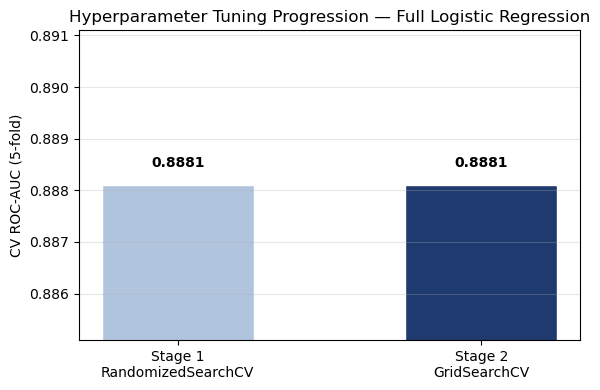

In [11]:
tuning_summary = [
    {
        'Stage':    'Stage 1\nRandomizedSearchCV',
        'C':        round(rand_search.best_params_['classifier__C'], 4),
        'l1_ratio': rand_search.best_params_['classifier__l1_ratio'],
        'CV AUC':   round(rand_search.best_score_, 4),
    },
    {
        'Stage':    'Stage 2\nGridSearchCV',
        'C':        round(grid_search.best_params_['classifier__C'], 4),
        'l1_ratio': grid_search.best_params_['classifier__l1_ratio'],
        'CV AUC':   round(grid_search.best_score_, 4),
    },
]

tuning_df = pd.DataFrame(tuning_summary).set_index('Stage')
print("Hyperparameter Tuning Progression — Full Logistic Regression")
print(tuning_df.to_string())

# Bar chart: CV AUC progression
aucs = [r['CV AUC'] for r in tuning_summary]
labels = [r['Stage'] for r in tuning_summary]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    labels,
    aucs,
    color=['#b0c4de', '#1e3a6e'],
    edgecolor='white',
    width=0.5
)

ax.set_ylim(min(aucs) - 0.003, max(aucs) + 0.003)
ax.set_ylabel("CV ROC-AUC (5-fold)")
ax.set_title("Hyperparameter Tuning Progression — Full Logistic Regression")

for bar, auc in zip(bars, aucs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"{auc:.4f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


The randomised and grid search stages both achieved the same cross-validated **ROC-AUC of 0.8881**, indicating that the Elastic Net model performs consistently across nearby hyperparameter values.

The grid search refined the regularisation strength from **C = 0.7727 to C = 0.3863** while retaining **l1_ratio = 0.3**, but this adjustment did not lead to any measurable improvement in performance.

This suggests that the model is not highly sensitive to small changes in the Elastic Net configuration, and that most of the predictive signal is already captured across a broad range of parameter values. The stability of performance across the search is itself informative: it confirms that the model is not overfitting to a narrow configuration.

In [12]:
# Rebuild full model with final grid-search parameters
best_C_final = grid_search.best_params_['classifier__C']
best_l1_final = grid_search.best_params_['classifier__l1_ratio']

full_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_full()),
    ('classifier', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=best_C_final,
        l1_ratio=best_l1_final,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

full_model.fit(X_train_full, y_train)

cv_scores_full = cross_val_score(
    full_model,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

baseline_cv_full = cross_val_score(
    full_model_base,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

print("Final Elastic Net Model — Full Feature Set")
print(f"C = {best_C_final:.4f}")
print(f"l1_ratio = {best_l1_final}")
print(f"CV ROC-AUC      : {cv_scores_full.mean():.4f} ± {cv_scores_full.std():.4f}")
print(f"Baseline CV AUC : {baseline_cv_full.mean():.4f}")
print(f"Delta vs baseline: {cv_scores_full.mean() - baseline_cv_full.mean():+.4f}")


Final Elastic Net Model — Full Feature Set
C = 0.3863
l1_ratio = 0.3
CV ROC-AUC      : 0.8881 ± 0.0217
Baseline CV AUC : 0.8881
Delta vs baseline: -0.0000


The final full model was therefore rebuilt using the grid-search parameters (C = 0.3863, l1_ratio = 0.3). This specification achieves a cross-validated ROC-AUC of 0.8881, with a standard deviation of 0.0217 across folds, indicating stable performance on the training data.

Importantly, this performance is effectively identical to that of the baseline model. This confirms that hyperparameter tuning does not materially improve discrimination, and that the baseline specification was already close to optimal.

The Elastic Net model is nevertheless retained, as it provides a more controlled and interpretable regularised structure, even in the absence of performance gains.

### 3.5 Threshold Tuning

By default, scikit-learn classifiers assign a positive prediction whenever the predicted probability exceeds 0.5. However, this threshold is rarely optimal in the presence of class imbalance.

In a marketing campaign context, the choice of threshold has direct business implications: setting it too low leads to unnecessary campaign costs by targeting customers who will not respond, while setting it too high results in missed opportunities by excluding customers who would have converted.

To determine the optimal cutoff, we evaluate the F1 score across all possible thresholds using out-of-fold cross-validation probabilities on the training set. This ensures that the threshold selection remains fully independent of the test data.

**F1** is used as the optimisation criterion because it balances precision and recall, rewarding thresholds that identify a high proportion of responders without generating excessive false positives.

The resulting optimal threshold replaces the default 0.5 and is applied to the test set for final evaluation, aligning the model’s decision rule with the business objective of efficient campaign targeting.

In [13]:
threshold_full = find_best_threshold_oof(full_model, X_train_full, y_train)

Optimal threshold (F1): 0.5928
Best OOF F1:            0.5758


### 3.6. Model Evaluation

The tuned model is evaluated on the held-out test set using the threshold selected through out-of-fold cross-validation.

This step provides an unbiased estimate of how the model will perform on new, unseen customers, as the test set has not been used in any stage of model training, tuning, or threshold selection.

In [14]:
y_prob_full = full_model.predict_proba(X_test_full)[:, 1]
y_pred_full = (y_prob_full >= threshold_full).astype(int)

full_eval = evaluate_model(full_model, X_test_full, y_test, "Full", threshold_full)
print("\nFinal Evaluation on Test Set — Full Model")
for metric, value in full_eval.items():
    print(f"{metric}: {value}")


Final Evaluation on Test Set — Full Model
Model: Full
Threshold: 0.5928
ROC-AUC: 0.8784
Precision: 0.48
Recall: 0.7164
F1: 0.5749
Accuracy: 0.8415


The full model achieves a **ROC-AUC of 0.88**, indicating strong discriminatory power: the model correctly ranks a random responder above a random non-responder 88% of the time. At the tuned threshold, **precision** stands at 48% and **recall** at 72%, yielding an **F1 of 0.58** — a substantial improvement over the 15% baseline response rate in the data.

These metrics provide complementary insights: ROC-AUC evaluates the model's ability to rank customers by likelihood of response regardless of any fixed threshold, while precision and recall reflect the practical trade-off between targeting efficiency and missed opportunities at the chosen operating point.

The model is tuned to capture a large share of true responders (72% recall) at the cost of some false positives (48% precision), meaning roughly 1 in 2 customers flagged as likely responders would actually convert. In a campaign context, where missing a subscriber is costlier than one wasted contact, this profile is well suited to the business objective.

To better understand how these trade-offs manifest in actual predictions, we examine the confusion matrix.

In [15]:
# Save LR full model probability scores and threshold for cross-notebook comparison
np.save('../data/lr_y_prob_full.npy', y_prob_full)
np.save('../data/lr_y_pred_full.npy', y_pred_full)
np.save('../data/lr_threshold_full.npy', np.array([threshold_full]))

print(f"LR probability scores saved: {len(y_prob_full)} predictions")
print(f"LR threshold saved: {threshold_full:.4f}")

LR probability scores saved: 448 predictions
LR threshold saved: 0.5928


### 3.7. Confusion Matrix

The confusion matrix below shows how the model's predictions compare to actual campaign responses across four outcomes:

- **True Positives (TP)**: customers correctly identified as likely to respond — the primary target of the campaign.
- **False Positives (FP)**: customers incorrectly flagged as likely responders — representing wasted campaign spend.
- **False Negatives (FN)**: actual responders the model missed — representing lost revenue opportunities.
- **True Negatives (TN)**: non-responders correctly excluded from the campaign — preserving budget.

In a marketing context, both FP and FN carry a real cost. The selected threshold determines where the model sits on the precision-recall trade-off, and the confusion matrix makes that trade-off explicit.
```

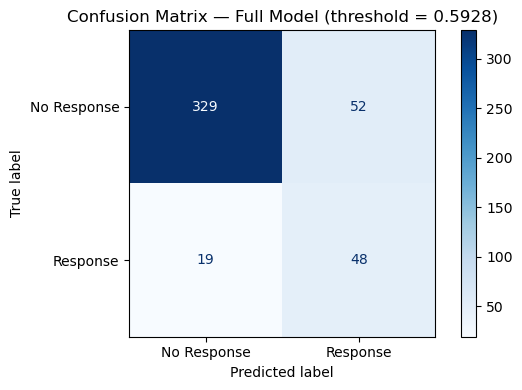

              precision    recall  f1-score   support

 No Response       0.95      0.86      0.90       381
    Response       0.48      0.72      0.57        67

    accuracy                           0.84       448
   macro avg       0.71      0.79      0.74       448
weighted avg       0.88      0.84      0.85       448



In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_full,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Full Model (threshold = {threshold_full:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_full,
                             target_names=['No Response', 'Response']))

The model correctly identifies **48 out of 67 actual responders** in the test set (recall of 72%), while generating a manageable number of false positives. Of all customers flagged by the model, approximately 48% are true responders — meaning that roughly 1 in 2 customers targeted would actually convert, compared to 1 in 7 under untargeted outreach.

This reflects a deliberate trade-off: the tuned threshold prioritises coverage of actual responders (high recall of 72%) over targeting precision (48%), which is appropriate in a campaign context where missing a subscriber is costlier than one wasted contact.

### 3.8. Precision-Recall Curve

The Precision-Recall curve illustrates the full trade-off between targeting precision and responder coverage across all possible classification thresholds, without fixing one upfront. Unlike the ROC curve, it focuses exclusively on the minority class — making it the more informative diagnostic in imbalanced settings.

A model with strong positive-class signal produces a curve that remains high across a wide range of recall values, indicating that it is possible to capture most responders without sacrificing too much precision. The vertical dashed line marks the selected operating threshold.

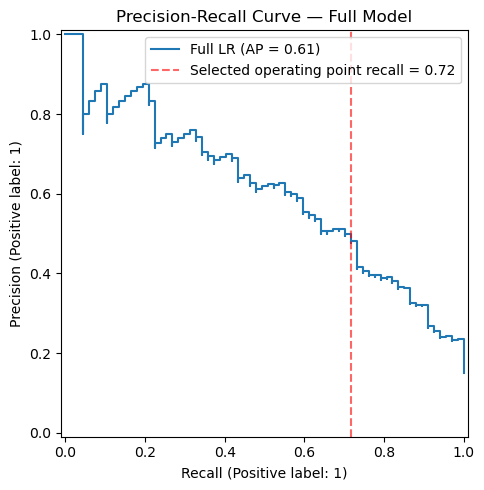

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_full,
    name=f"Full LR",
    ax=ax
)

selected_recall_full = recall_score(y_test, y_pred_full)
ax.axvline(
    selected_recall_full,
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Selected operating point recall = {selected_recall_full:.2f}'
)

ax.set_title("Precision-Recall Curve — Full Model")
ax.legend()
plt.tight_layout()
plt.show()


At the selected operating point, the model achieves a recall of 72% while maintaining a precision of 48%. The curve remains reasonably elevated through moderate recall levels before declining more steeply, indicating that the threshold is placed in a region where both objectives are reasonably satisfied. Shifting the threshold rightward would recover more responders at the cost of lower precision, which may be warranted if campaign costs are low relative to the value of each conversion.

### 3.9. ROC Curve

The ROC curve measures the model's ability to rank customers by their likelihood of responding, across all possible thresholds. The AUC summarises this into a single number: the probability that a randomly chosen responder is ranked higher
than a randomly chosen non-responder.

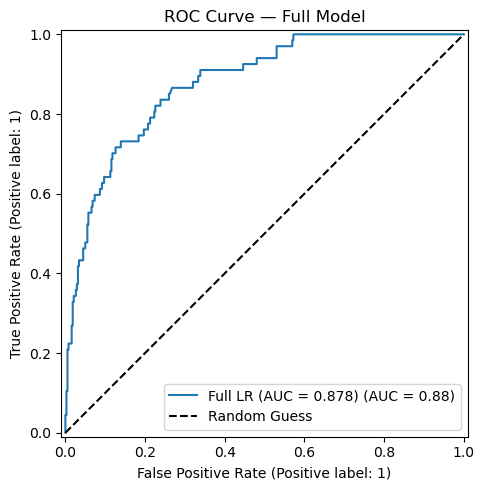

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_full,
    name=f"Full LR (AUC = {roc_auc_score(y_test, y_prob_full):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax.set_title("ROC Curve — Full Model")
ax.legend()
plt.tight_layout()
plt.show()

The full model achieves an AUC of **0.88** on the test set, confirming strong discriminatory ability: the model ranks a randomly selected responder above a randomly selected non-responder 88% of the time. This is a substantial improvement over the 0.50 baseline of a random classifier, and provides confidence that the model's probability scores can be used reliably for customer ranking and tiered targeting strategies — even when the classification threshold is adjusted.

### 3.10 Calibration

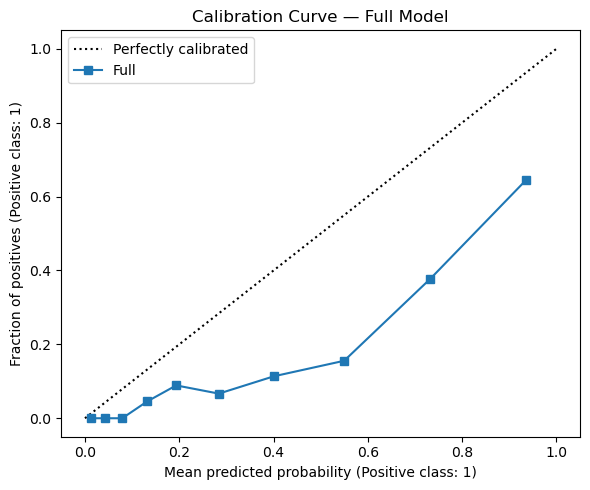

In [19]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test, y_prob_full,
    n_bins=10,
    strategy='quantile',
    name='Full',
    ax=ax
)

ax.set_title("Calibration Curve — Full Model")
ax.legend()
plt.tight_layout()
plt.show()


The calibration curve shows that the full model is not well calibrated: the predicted probabilities lie consistently below the 45-degree reference line, indicating that the model tends to be overconfident. Customers assigned high predicted response probabilities convert at lower rates than the model suggests.

In practical terms, this means the model's raw probability scores should not be used directly as estimates of expected conversion rate, for example, when calculating expected ROI per customer. However, the model remains fully valid for **ranking and prioritising customers**, since the relative ordering of predicted probabilities is preserved even when the absolute values are miscalibrated.

If probability estimates are needed for downstream decision-making (e.g., budget allocation or bid optimisation), calibration post-processing, such as Platt scaling or isotonic regression, should be applied before deployment.

### 3.11. Learning Curves

Learning curves show how model performance changes as the amount of training data increases. They allow us to assess whether the model is suffering from **overfitting or underfitting**, and whether additional training data could improve performance.

- If the training score is much higher than the validation score, the model may be **overfitting**.
- If both scores are low, the model may be **underfitting**.

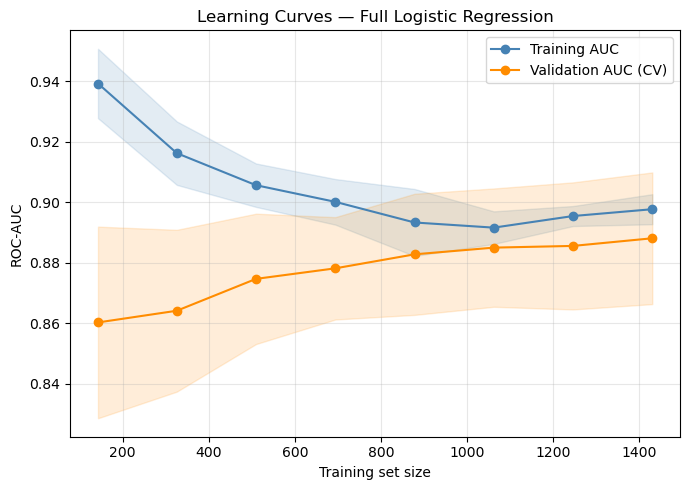

In [20]:
train_sizes, train_scores, val_scores = learning_curve(
    full_model, X_train_full, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(train_sizes, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(train_sizes, val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='darkorange')
ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Full Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The learning curves show that training and validation AUC converge smoothly as the training set grows, with no persistent gap between the two. This suggests that the model is well-balanced, neither overfitting to the training data nor underfitting due to insufficient model capacity.

The convergence point appears to be reached before the full training set is used, indicating that the model has effectively extracted the available signal from the current dataset. Collecting additional observations would likely yield only marginal performance gains, unless new feature types or richer behavioural data become available.

### 3.12. Feature Importance (Coefficients)
Having established strong predictive performance, we now examine which variables drive the model’s predictions.

Logistic regression coefficients represent the change in log-odds of responding for a one-unit increase in a standardised feature, holding all others constant. 
Exponentiated as odds ratios, they quantify the multiplicative change in the odds of response. Features zeroed out by the L1 component of Elastic Net are excluded from the plot.

In [21]:
ohe_full = full_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_full = ohe_full.get_feature_names_out(categorical_features_full).tolist()
all_names_full = numerical_features_full + cat_names_full

coefs_full = full_model.named_steps['classifier'].coef_[0]

coef_df_full = pd.DataFrame({
    'Feature': all_names_full,
    'Coefficient': coefs_full,
    'Odds Ratio': np.exp(coefs_full)
}).sort_values(by='Coefficient', ascending=False)

n_zeroed = (coef_df_full['Coefficient'] == 0).sum()
print(f"Features retained by L1 : {len(coef_df_full) - n_zeroed} / {len(coef_df_full)}")
print(f"Features zeroed out: {n_zeroed}\n")

coef_df_full.round(4)

Features retained by L1 : 19 / 20
Features zeroed out: 1



,Feature,Coefficient,Odds Ratio
6,Total_Accepted_Campaigns,1.0798,2.9440
3,Customer_Tenure,0.9588,2.6086
14,Education_PhD,0.8962,2.4504
4,Total_Spending,0.4412,1.5545
19,Marital_Status_Widow,0.2911,1.3379
7,NumDealsPurchases,0.2850,1.3298
8,NumWebVisitsMonth,0.1897,1.2089
1,Income,0.1831,1.2009
9,Kidhome,0.1758,1.1922
0,Age,0.1562,1.1691


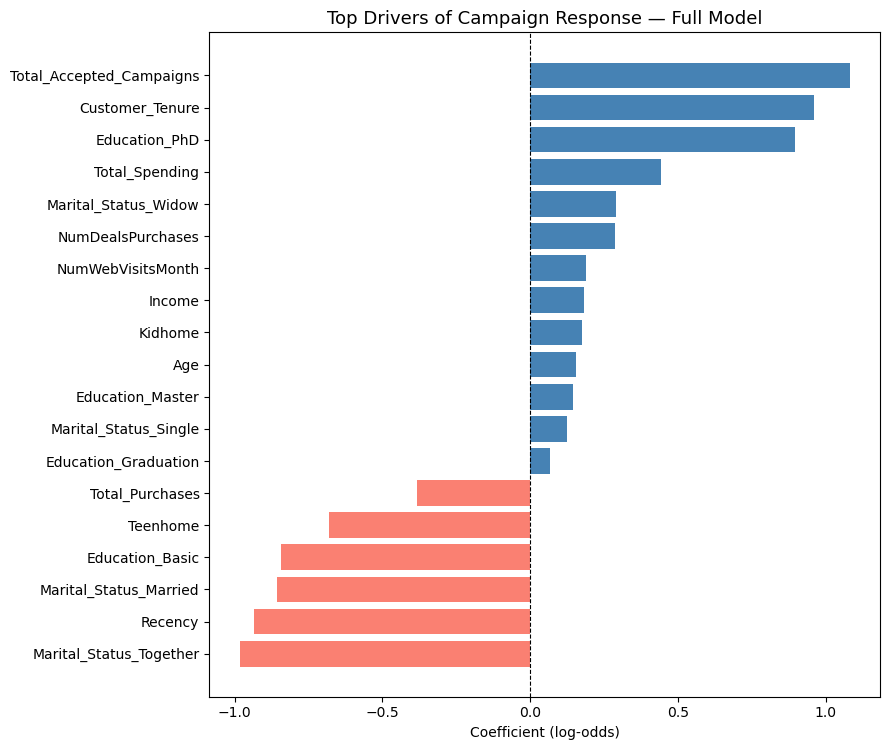

In [22]:
coef_df_full_nonzero = coef_df_full[coef_df_full['Coefficient'] != 0].copy()
coef_df_full_nonzero = coef_df_full_nonzero.sort_values('Coefficient', ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_full_nonzero['Coefficient']]
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_full_nonzero) * 0.4)))
ax.barh(coef_df_full_nonzero['Feature'], coef_df_full_nonzero['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Full Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 3.13. Permutation Importance

To obtain a more robust measure of feature importance, we compute permutation importance on the test set. This method evaluates the contribution of each feature by randomly shuffling its values and measuring the resulting drop in model performance.

If shuffling a feature leads to a large decrease in ROC-AUC, it indicates that the feature plays an important role in the model’s predictions.

Permutation Importance — Full Model (test set):

                 Feature  Importance_Mean  Importance_Std
Total_Accepted_Campaigns         0.115756        0.012034
                 Recency         0.073532        0.006506
         Customer_Tenure         0.044874        0.014716
          Marital_Status         0.029269        0.004676
          Total_Spending         0.026356        0.006461
                Teenhome         0.023081        0.013576
               Education         0.014853        0.004121
       NumDealsPurchases         0.014304        0.003983
                  Income         0.005763        0.003052
       NumWebVisitsMonth         0.003267        0.003666
                     Age         0.002092        0.002314
                 Kidhome         0.001026        0.002479
         Total_Purchases        -0.001514        0.006191


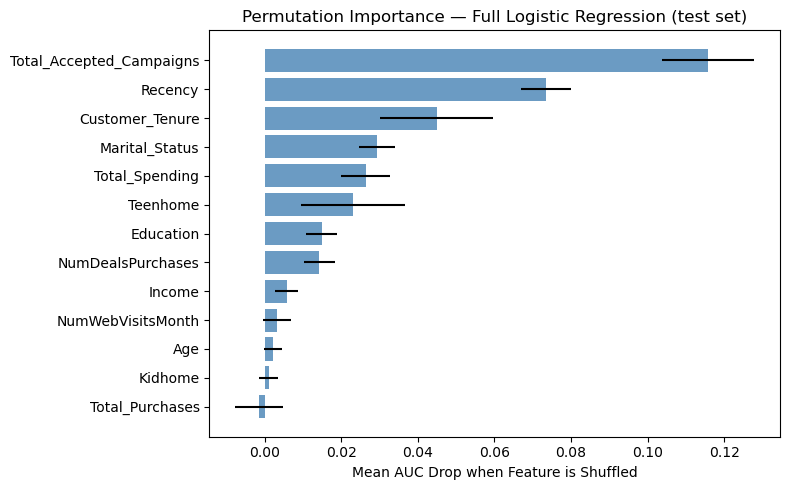

In [23]:
raw_feature_names = numerical_features_full + categorical_features_full

perm_result = permutation_importance(
    full_model, X_test_full, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df = pd.DataFrame({
    'Feature':         raw_feature_names,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std':  perm_result.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Full Model (test set):\n")
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
top_perm = perm_df.sort_values('Importance_Mean')
ax.barh(top_perm['Feature'], top_perm['Importance_Mean'],
        xerr=top_perm['Importance_Std'], color='steelblue', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Full Logistic Regression (test set)")
plt.tight_layout()
plt.show()

The permutation results confirm that `Total_Accepted_Campaigns` and `Recency` account for the largest individual drops in AUC when shuffled, reinforcing their role as the primary drivers of model performance. `Total_Spending` and `Customer_Tenure` follow, while demographic features such as `Kidhome`, `Teenhome`, and the categorical variables contribute more modestly.

This pattern is consistent with the coefficient analysis in Section 3.12 and supports the interpretation that behavioural engagement history, rather than customer demographics alone, is the primary signal of campaign receptiveness.

### 3.14. SHAP Values

To further interpret the model, we compute SHAP (SHapley Additive exPlanations) values. SHAP quantifies how each feature contributes to the model’s prediction by measuring how much it increases or decreases the predicted probability relative to a baseline.

`LinearExplainer` is used here as it is the appropriate and efficient SHAP method for logistic regression.

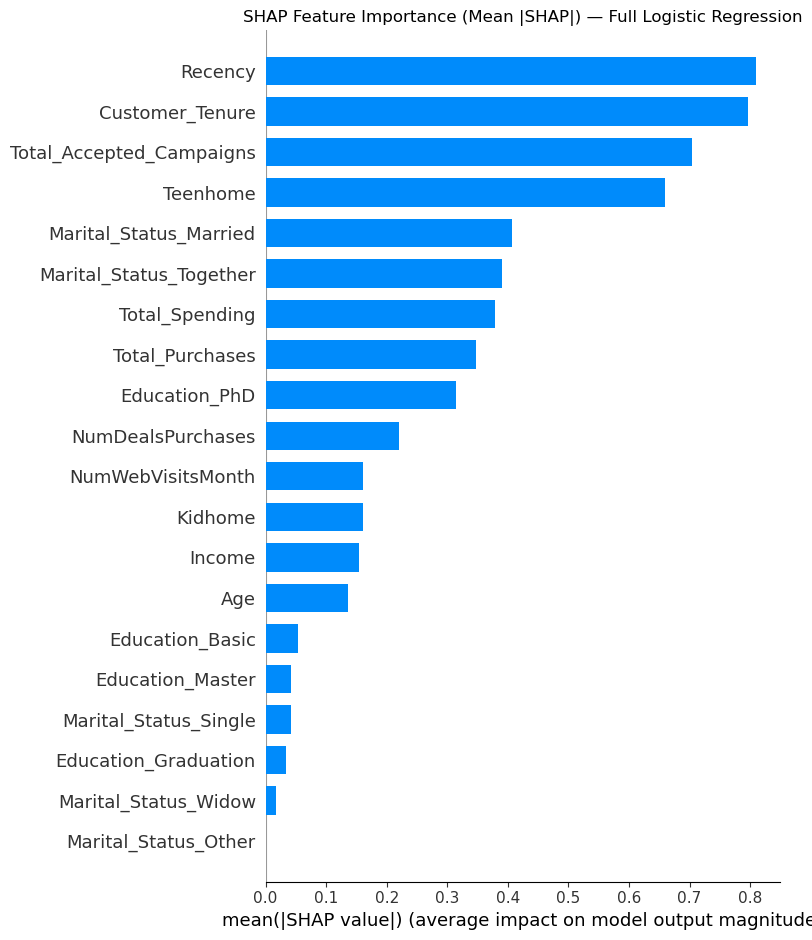

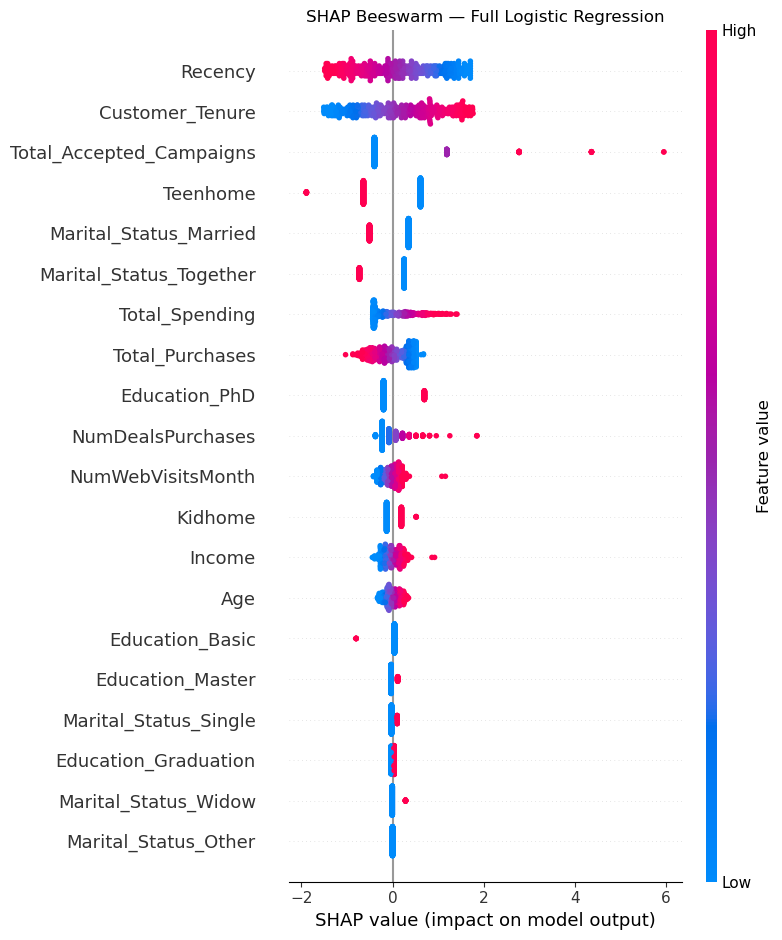

In [24]:
X_test_transformed  = full_model.named_steps['preprocessor'].transform(X_test_full)
X_train_transformed = full_model.named_steps['preprocessor'].transform(X_train_full)

explainer   = shap.LinearExplainer(
    full_model.named_steps['classifier'],
    X_train_transformed,
    feature_perturbation='interventional'
)
shap_values = explainer.shap_values(X_test_transformed)

# Global summary: bar chart
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_names_full,
                  plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Full Logistic Regression")
plt.tight_layout()
plt.show()

# Global beeswarm: direction + magnitude
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_names_full, show=False)
plt.title("SHAP Beeswarm — Full Logistic Regression")
plt.tight_layout()
plt.show()

The SHAP beeswarm confirms and extends the coefficient analysis. `Total_Accepted_Campaigns` shows the widest dispersion and the largest positive SHAP values: customers with a high acceptance history consistently receive a strong upward push in predicted probability. `Recency` produces the largest negative SHAP values at the upper end of its distribution, customers who have not purchased recently are strongly pushed toward non-response.

Notably, the SHAP values also reveal heterogeneity: for variables like `Total_Spending` and `Income`, the effect is concentrated among customers at the upper end of the distribution, while mid-range values contribute little predictive signal. This kind of non-linear concentration is captured by SHAP even within the linear logistic regression framework, because it reflects the underlying data distribution rather than the model's functional form.

### 3.15. Interpretation of Full Model Results

The full logistic regression model provides a comprehensive view of the factors influencing campaign response. It uses Elastic Net regularisation with an optimal `l1_ratio` of 0.3, indicating that the penalty leans closer to L2 than L1, shrinking most coefficients rather than eliminating them, which is appropriate given the moderate correlations among the engineered features.

The model achieves a **ROC-AUC** of 0.88 and an **F1** of 0.58 on the positive class, with the tuned threshold of 0.5928 correctly identifying 48 out of 67 actual responders (**recall** of 72%) while maintaining a **precision** of 48% — meaning that roughly 1 in 2 customers targeted by the model would actually convert, a substantial improvement over the 15% baseline.

Among the positive indicators, past campaign acceptance is the strongest predictor (OR = 2.9440), followed by `Customer_Tenure` (OR = 2.6086) and `Education_PhD` (OR = 2.4504), indicating that long-standing, highly educated customers with a history of engagement are the most responsive. `Total_Spending` (OR = 1.5545), `Income` (OR = 1.2009), and `Education_Master` (OR = 1.1537) all suggest that higher-value, better-educated customers respond more frequently.

On the negative side, `Marital_Status_Together` (OR = 0.3743) and `Marital_Status_Married` (OR = 0.4240) are the strongest deterrents, followed by `Recency` (OR = 0.3929) and `Education_Basic` (OR = 0.4310), indicating that recently inactive customers in shared households with lower education levels are significantly less likely to respond. `Teenhome` (OR = 0.5067) and `Total_Purchases` (OR = 0.6820) also reduce response probability.

Only `Marital_Status_Other` was zeroed out by the Elastic Net penalty, confirming that the L2 component successfully retained most features rather than discarding correlated ones, as a pure L1 penalty would have done.

Overall, the full model shows that campaign response is driven by a combination of behavioural engagement and customer profile. To better understand the relative contribution of each dimension, we now estimate two targeted models that isolate behavioural and demographic effects separately.

## 4. Behavioural Model — No Regularisation

To better understand the role of customer engagement and purchasing behaviour in campaign response, a logistic regression model is estimated using only behavioural variables: `Recency`, `Total_Spending`, `Total_Purchases`, `Total_Accepted_Campaigns`, `NumDealsPurchases`, and `NumWebVisitsMonth`.

These six features capture what a customer *does*, how recently they engaged, how much they spend, and whether they have responded to past campaigns, rather than who they are demographically. The EDA identified behavioural variables as the strongest individual predictors of response, and the full model confirmed their dominance through coefficient magnitude and permutation importance.

This model tests whether behavioural signals alone are sufficient for effective targeting, which has a direct operational implication: if behavioural data is available, it may be possible to build a competitive targeting model without requiring demographic profiling.

In [86]:
# Helper: fresh preprocessor for behavioural model
def make_preprocessor_behav():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_behav)
    ])

### 4.1. Baseline Model

In [87]:
# Baseline: sklearn defaults (L2, C=1.0) with class_weight='balanced'
behav_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_behav()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])
baseline_auc_behav = cross_val_score(
    behav_model_base,
    X_train_behav,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

baseline_f1_behav = cross_val_score(
    behav_model_base,
    X_train_behav,
    y_train,
    cv=cv_strategy,
    scoring='f1'
)

baseline_recall_behav = cross_val_score(
    behav_model_base,
    X_train_behav,
    y_train,
    cv=cv_strategy,
    scoring='recall'
)

print("Baseline Logistic Regression — Behavioural Model (training CV only)")
print(f"ROC-AUC : {baseline_auc_behav.mean():.4f} ± {baseline_auc_behav.std():.4f}")
print(f"Recall  : {baseline_recall_behav.mean():.4f} ± {baseline_recall_behav.std():.4f}")
print(f"F1      : {baseline_f1_behav.mean():.4f} ± {baseline_f1_behav.std():.4f}")

Baseline Logistic Regression — Behavioural Model (training CV only)
ROC-AUC : 0.8333 ± 0.0271
Recall  : 0.6967 ± 0.0546
F1      : 0.4914 ± 0.0444


The baseline behavioural model already achieves a cross-validated ROC-AUC of approximately 0.833, demonstrating that six engagement variables alone capture a substantial portion of the predictive signal identified in the full model. This confirms the EDA finding that behavioural history is the dominant driver of campaign response.

Recall is high (0.6967), indicating the model already recovers most true responders even without tuning, though F1 (0.4914) remains moderate, reflecting the precision-recall trade-off under class imbalance. This sets a strong benchmark for the regularisation comparison that follows.

> **Methodological note:** To preserve an unbiased final evaluation, the test set is used only once — at the end of each model's pipeline, after all training, regularisation selection, hyperparameter tuning, and threshold optimisation decisions have been made exclusively on the training set using cross-validation.

### 4.2 Regularisation Strategy Selection

The same four regularisation strategies compared for the full model (no penalty, L2, L1, and Elastic Net) are evaluated here on the behavioural feature set at a fixed `C = 1.0`.

The behavioural features are all continuous and largely independent, there are no strongly correlated engineered aggregates that would favour one penalty type over another. As a result, regularisation may be less necessary here than in the full model. This comparison tests that assumption empirically, using 5-fold stratified cross-validation with ROC-AUC as the criterion.

In [88]:
reg_results_behav = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_behav()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_behav, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results_behav.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df_behav = pd.DataFrame(reg_results_behav).set_index('Regularisation')
print("Regularisation Strategy Comparison — Behavioural Model (C=1.0, untuned)\n")
print(reg_df_behav.to_string())

Regularisation Strategy Comparison — Behavioural Model (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.8334      0.0270
L2 (Ridge)              0.8333      0.0271
L1 (Lasso)              0.8330      0.0270
Elastic Net             0.8331      0.0269


### 4.3 Preprocessing & Behavioural Logistic Regression

The regularisation comparison in Section 4.2 shows that all four penalty options perform identically (CV AUC range: 0.8330–0.8334), confirming that regularisation does not provide any measurable benefit for this feature set.

`penalty=None` is therefore used. No hyperparameter tuning is required, as the unregularised specification has no penalty parameters to optimise.

In [89]:
# Behavioural Logistic Regression — No Regularisation
behav_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_behav()),
    ('classifier', LogisticRegression(
        penalty=None,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

behav_model.fit(X_train_behav, y_train)

# CV score on training set
cv_scores_behav = cross_val_score(
    behav_model, X_train_behav, y_train,
    cv=cv_strategy, scoring='roc_auc'
)
print(f"CV ROC-AUC : {cv_scores_behav.mean():.4f} ± {cv_scores_behav.std():.4f}")

# Improvement over baseline
baseline_cv_behav = baseline_auc_behav.mean()

print(f"\nBaseline CV AUC : {baseline_cv_behav:.4f}")
print(f"No-reg CV AUC   : {cv_scores_behav.mean():.4f}  "
      f"(Δ = {cv_scores_behav.mean() - baseline_cv_behav:+.4f})")

CV ROC-AUC : 0.8334 ± 0.0270

Baseline CV AUC : 0.8333
No-reg CV AUC   : 0.8334  (Δ = +0.0001)


The unregularised model maintains a cross-validated ROC-AUC of 0.8334, effectively identical to the regularised baseline (Δ = +0.0001), confirming that penalty=None is the appropriate specification for this feature set.

### 4.4. Threshold Tuning

The optimal threshold is selected by maximising F1 across all possible cutoffs using out-of-fold cross-validation probabilities on the training set only, ensuring no test data influences the selection.
As in the full model, this ensures that the decision threshold reflects the trade-off between campaign efficiency and missed opportunities.

In [90]:
threshold_behav = find_best_threshold_oof(behav_model, X_train_behav, y_train)

Optimal threshold (F1): 0.6148
Best OOF F1:            0.5268


The optimal threshold is 0.6148, slightly above the default 0.5, maximising OOF F1 at 0.5268 on the training set. This threshold will be applied to the test set in the next section.

### 4.5. Model Evaluation

In [91]:
## Predictions and evaluation on test set
y_prob_behav = behav_model.predict_proba(X_test_behav)[:,1]
y_pred_behav = (y_prob_behav >= threshold_behav).astype(int)

behav_eval = evaluate_model(behav_model, X_test_behav, y_test, "Behavioural", threshold_behav)
print("\nFinal Evaluation on Test Set — Behavioural Model")
for metric, value in behav_eval.items():
    print(f"{metric}: {value}")


Final Evaluation on Test Set — Behavioural Model
Model: Behavioural
Threshold: 0.6148
ROC-AUC: 0.8588
Precision: 0.5
Recall: 0.5224
F1: 0.5109
Accuracy: 0.8504


The behavioural model achieves a **ROC-AUC of 0.86** on the test set — only 3 percentage points below the full model, despite using just six features compared to the full model's thirteen. At the tuned threshold, the model correctly identifies **35 out of 67 actual responders (recall of 52%)**, with a **precision of 50%**, meaning 1 in 2 customers flagged as likely responders would actually convert. This confirms that customer engagement history alone captures most of the predictive signal available in the data.

### 4.6 Confusion Matrix

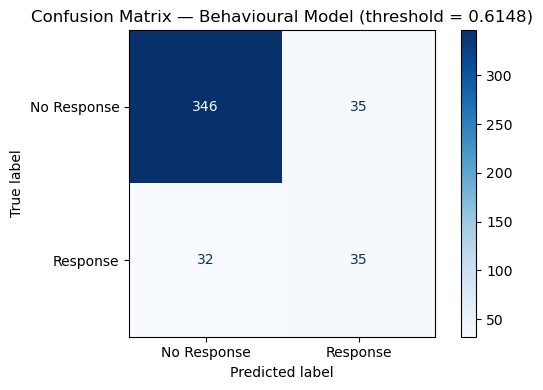

              precision    recall  f1-score   support

 No Response       0.92      0.91      0.91       381
    Response       0.50      0.52      0.51        67

    accuracy                           0.85       448
   macro avg       0.71      0.72      0.71       448
weighted avg       0.85      0.85      0.85       448



In [92]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_behav,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Behavioural Model (threshold = {threshold_behav:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_behav,
                             target_names=['No Response', 'Response']))

The confusion matrix confirms that the model correctly identifies 35 out of 67 actual responders (TP = 35, recall = 52%), while generating 35 false positives. Of all 70 customers flagged by the model, 50% are true responders, meaning the company would need to contact 2 customers for every true responder reached, a meaningful improvement over untargeted outreach where the ratio is approximately 6.7 to 1.

Compared to the full model (48 true positives, recall of 72%), the behavioural model captures fewer responders. However, it maintains equivalent precision (50% vs 48%) with a much simpler feature set, making it an efficient and deployable alternative where demographic data is unavailable.

### 4.7. Precision-Recall Curve

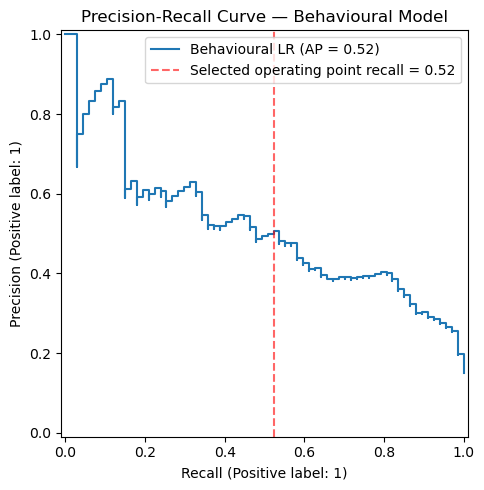

In [93]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_behav,
    name=f"Behavioural LR",
    ax=ax
)

selected_recall_behav = recall_score(y_test, y_pred_behav)
ax.axvline(
    selected_recall_behav,
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Selected operating point recall = {selected_recall_behav:.2f}'
)

ax.set_title("Precision-Recall Curve — Behavioural Model")
ax.legend()
plt.tight_layout()
plt.show()


At the selected operating point (recall = 0.52), the model achieves a precision of 50%. The curve declines more steeply than the full model at higher recall values, reflecting the reduced feature set's limited ability to recover the remaining responders without substantially increasing false positives. Shifting the threshold leftward would recover additional responders at the cost of precision, which may be warranted if subscriber acquisition value is high relative to contact cost.

### 4.8 ROC Curve

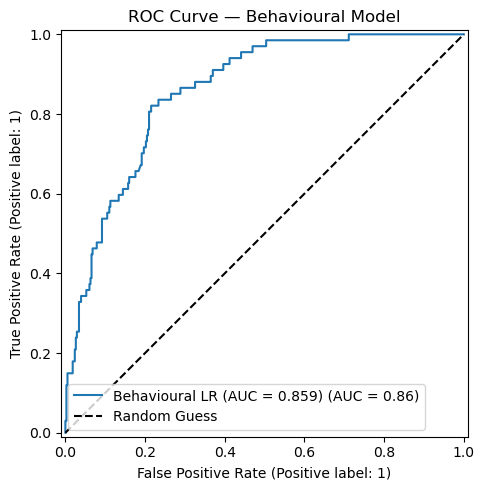

In [94]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_behav,
    name=f"Behavioural LR (AUC = {roc_auc_score(y_test, y_prob_behav):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title("ROC Curve — Behavioural Model")
ax.legend()
plt.tight_layout()
plt.show()

The behavioural model achieves an AUC of 0.859 on the test set, confirming strong discriminatory ability with only six features. The model ranks a randomly selected responder above a randomly selected non-responder approximately 86% of the time, only 2 percentage points below the full model's 0.88 (demonstrating that behavioural history alone captures the vast majority of the ranking signal available in the data).

### 4.9 Calibration

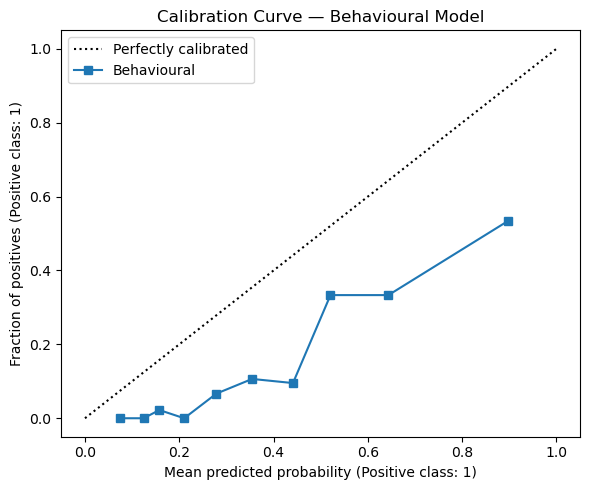

In [102]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test, y_prob_behav,
    n_bins=10,
    strategy='quantile',
    name='Behavioural',
    ax=ax
)

ax.set_title("Calibration Curve — Behavioural Model")
ax.legend()
plt.tight_layout()
plt.show()


The calibration curve reveals poor calibration: predicted probabilities are systematically below the diagonal. This indicates that the model is generally overconfident, assigning lower probabilities than the actual conversion rate warrants. As with the full model, probability scores should be used for ranking customers rather than as direct estimates of conversion rate.

### 4.10 Learning Curves

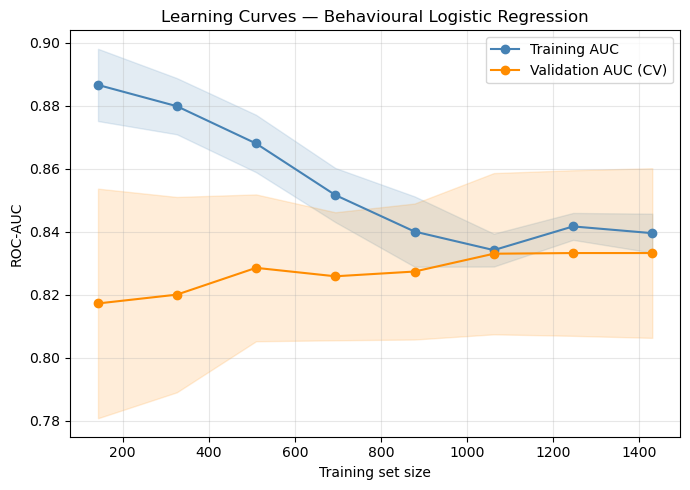

In [96]:
train_sizes, train_scores, val_scores = learning_curve(
    behav_model,
    X_train_behav,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='steelblue'
)
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color='darkorange'
)

ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Behavioural Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The learning curves show a persistent gap between training AUC (~0.84–0.89) and validation AUC (~0.82–0.83) across all training sizes, with both curves converging slowly as data increases. 
This suggests mild overfitting: the model fits the training data more tightly than it generalises to unseen observations, likely driven by the compact six-feature set. The validation AUC stabilises around 0.83, indicating that the model has largely extracted the available signal from the current dataset. Collecting additional training observations would likely yield only marginal improvements unless new behavioural features become available.

### 4.11. Feature Importance (Coefficients)

Since no regularisation is applied, all coefficients are estimated without penalty shrinkage. They represent the change in log-odds of responding for a one-unit increase in each standardised feature, holding the others constant. Exponentiated as odds ratios, they quantify the multiplicative change in response probability associated with each variable.

In [97]:
coefs_behav = behav_model.named_steps['classifier'].coef_[0]

coef_df_behav = pd.DataFrame({
    'Feature':     numerical_features_behav,
    'Coefficient': coefs_behav,
    'Odds Ratio':  np.exp(coefs_behav)
}).sort_values('Coefficient', ascending=False)

coef_df_behav.round(4)

,Feature,Coefficient,Odds Ratio
1,Total_Spending,0.9916,2.6955
3,Total_Accepted_Campaigns,0.8397,2.3156
5,NumWebVisitsMonth,0.5869,1.7984
4,NumDealsPurchases,0.1009,1.1062
2,Total_Purchases,-0.3803,0.6836
0,Recency,-0.7260,0.4839


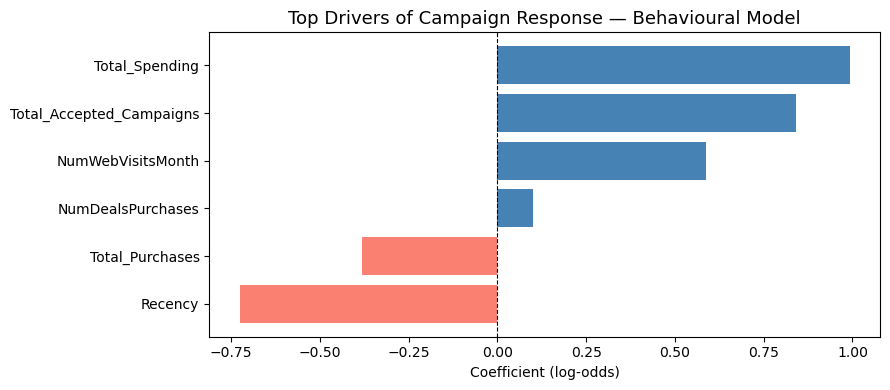

In [98]:
coef_df_behav_sorted = coef_df_behav.sort_values('Coefficient', ascending=True)
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_behav_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_behav_sorted) * 0.4)))
ax.barh(coef_df_behav_sorted['Feature'], coef_df_behav_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Behavioural Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 4.12. Permutation Importance

Permutation Importance — Behavioural Model (test set):

                 Feature  Importance_Mean  Importance_Std
          Total_Spending         0.177060        0.021104
Total_Accepted_Campaigns         0.137180        0.016633
                 Recency         0.096868        0.008466
       NumWebVisitsMonth         0.051001        0.018481
         Total_Purchases         0.010646        0.008986
       NumDealsPurchases         0.005612        0.002068


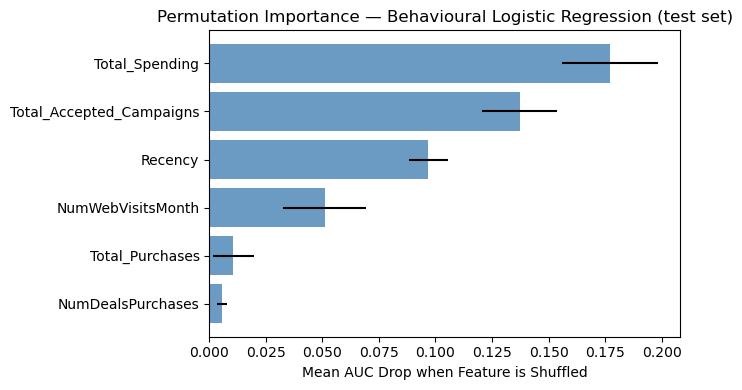

In [99]:
perm_result_behav = permutation_importance(
    behav_model, X_test_behav, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df_behav = pd.DataFrame({
    'Feature':         numerical_features_behav,
    'Importance_Mean': perm_result_behav.importances_mean,
    'Importance_Std':  perm_result_behav.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Behavioural Model (test set):\n")
print(perm_df_behav.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
top_perm_behav = perm_df_behav.sort_values('Importance_Mean')
ax.barh(top_perm_behav['Feature'], top_perm_behav['Importance_Mean'],
        xerr=top_perm_behav['Importance_Std'], color='steelblue', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Behavioural Logistic Regression (test set)")
plt.tight_layout()
plt.show()

The permutation importance results confirm that Total_Spending (mean AUC drop = 0.177) and Total_Accepted_Campaigns (0.137) are the two most critical features (shuffling either produces the largest drop in AUC). 
Recency follows at 0.097, and NumWebVisitsMonth at 0.051. Total_Purchases and NumDealsPurchases contribute minimally (0.011 and 0.006 respectively), suggesting they add little independent predictive signal once the other features are accounted for.
Notably, permutation importance ranks Total_Spending above Total_Accepted_Campaigns, whereas the coefficients placed them in the same order. This is consistent as permutation importance measures the actual performance drop on the test set, which reflects both coefficient magnitude and feature variance.

### 4.13. SHAP Values

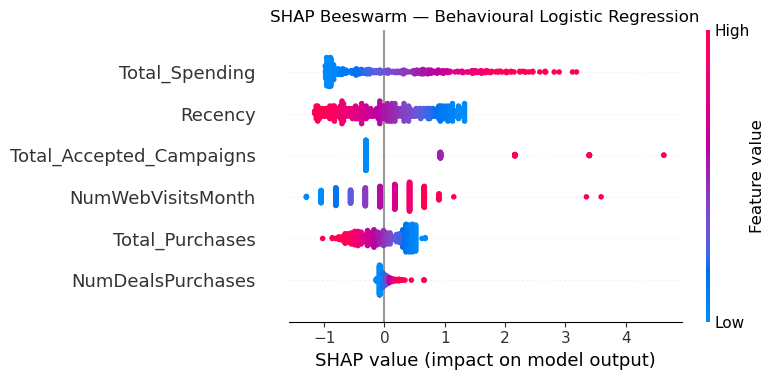

In [100]:
X_behav_test_t  = behav_model.named_steps['preprocessor'].transform(X_test_behav)
X_behav_train_t = behav_model.named_steps['preprocessor'].transform(X_train_behav)

explainer_behav   = shap.LinearExplainer(
    behav_model.named_steps['classifier'],
    X_behav_train_t,
    feature_perturbation='interventional'
)
shap_values_behav = explainer_behav.shap_values(X_behav_test_t)

shap.summary_plot(shap_values_behav, X_behav_test_t,
                  feature_names=numerical_features_behav, show=False)
plt.title("SHAP Beeswarm — Behavioural Logistic Regression")
plt.tight_layout()
plt.show()

`Total_Spending` shows the widest rightward dispersion: customers with high spending consistently receive a strong upward push in predicted probability, with some extreme positive SHAP values above 3.0. 
`Recency` produces the largest leftward SHAP values — customers with high recency (i.e. who have not purchased recently) are strongly pushed toward non-response.
`Total_Accepted_Campaigns` shows a distinct pattern: most customers cluster near zero SHAP impact, but a subset with high acceptance history receives a large positive push, reflecting that this variable is skewed, with most customers having zero prior acceptances. 
`Total_Purchases` and `NumDealsPurchases` contribute minimal signal, consistent with the permutation importance results.

### 4.14. Interpretation of Behavioural Model Results

The behavioural model achieves a **ROC-AUC of 0.86**, indicating strong discriminatory ability with only six engagement variables. At the tuned threshold of 0.6148, the model correctly identifies 35 out of 67 actual responders (**recall of 52%, precision of 50%**), meaning that 1 in 2 customers flagged as likely responders would actually convert, a significant improvement over the 15% baseline.

Among the positive drivers, `Total_Spending` is the strongest predictor (OR = 2.70), indicating that higher-value customers are significantly more likely to respond. `Total_Accepted_Campaigns` follows closely (OR = 2.32), reinforcing that prior campaign engagement is a clear signal of future receptiveness. 

`NumWebVisitsMonth` also has a positive effect (OR = 1.80), which likely reflects a suppressor effect: once spending and recency are controlled for, frequent web visitors who still spend heavily signal active interest rather than passive browsing. `NumDealsPurchases` has a modest positive effect (OR = 1.11).

On the negative side, `Recency` has the largest negative coefficient (OR = 0.48), confirming that customers who have not purchased recently are significantly less likely to respond. `Total_Purchases` also carries a negative coefficient (OR = 0.68), suggesting that customers who concentrate their spending in fewer, higher-value transactions are more responsive than those making frequent smaller purchases.

The behavioural model performs close to the full model at a fraction of the feature cost, making it the most practical candidate for deployment where customer transaction history is available. To assess what demographics contribute independently, we now estimate the demographic model.

## 5. Demographic Model - L1 Regularisation 

The demographic model uses only customer profile and household composition 
variables. While the five numerical features are largely independent, the 
categorical variables `Education` and `Marital_Status` expand to approximately 
14 columns after one-hot encoding, and several categories (particularly `Widow` 
and `Other`) contain very few observations.

Without regularisation, coefficients on sparse categories can become inflated 
and unstable, driven by small sample artefacts rather than genuine signal. 
The regularisation strategy is selected empirically in Section 5.2 — L1 is 
chosen over L2 and Elastic Net because zeroing out coefficients on uninformative 
sparse categories is preferable to merely shrinking them, reducing the risk of 
low-frequency categories driving predictions.

In [103]:
# Helper: fresh preprocessor for demographic model
def make_preprocessor_demo():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_demo),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features_demo)
    ])

### 5.1. Baseline Model


In [104]:
# Baseline: sklearn defaults (L2, C=1.0) with class_weight='balanced'
demo_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_demo()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

baseline_auc_demo = cross_val_score(
    demo_model_base,
    X_train_demo,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

baseline_f1_demo = cross_val_score(
    demo_model_base,
    X_train_demo,
    y_train,
    cv=cv_strategy,
    scoring='f1'
)

baseline_recall_demo = cross_val_score(
    demo_model_base,
    X_train_demo,
    y_train,
    cv=cv_strategy,
    scoring='recall'
)

print("Baseline Logistic Regression — Demographic Model (training CV only)")
print(f"ROC-AUC : {baseline_auc_demo.mean():.4f} ± {baseline_auc_demo.std():.4f}")
print(f"Recall  : {baseline_recall_demo.mean():.4f} ± {baseline_recall_demo.std():.4f}")
print(f"F1      : {baseline_f1_demo.mean():.4f} ± {baseline_f1_demo.std():.4f}")


Baseline Logistic Regression — Demographic Model (training CV only)
ROC-AUC : 0.7517 ± 0.0242
Recall  : 0.6887 ± 0.0562
F1      : 0.4059 ± 0.0233


The baseline demographic model achieves a cross-validated ROC-AUC of approximately 0.75, noticeably lower than the behavioural baseline (0.833) and the full model baseline (0.888). This is consistent with the EDA finding that demographic variables are inherently weaker individual predictors of campaign response — customer profile tells us something about who might be receptive, but not nearly as much as what they have actually done. The gap sets a clear ceiling expectation for this model before regularisation and tuning are applied.

### 5.2 Regularisation Strategy Selection


The same four penalty options are compared at `C = 1.0` using 5-fold stratified cross-validation on the demographic feature set.

The demographic feature set is structurally different from the behavioural one: while the five numerical variables are largely independent, the categorical variables `Education` and `Marital_Status` expand to approximately 14 columns after one-hot encoding, several of which correspond to sparse categories (`Widow`, `Other`) with very few observations. In this context, regularisation plays a more important role than in the behavioural model — sparse categories are prone to inflated, unstable coefficients when left unpenalised. The comparison here tests which penalty structure best controls for this instability.

In [105]:
reg_results_demo = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_demo()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_demo, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results_demo.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df_demo = pd.DataFrame(reg_results_demo).set_index('Regularisation')
print("Regularisation Strategy Comparison — Demographic Model (C=1.0, untuned)\n")
print(reg_df_demo.to_string())

Regularisation Strategy Comparison — Demographic Model (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.7449      0.0242
L2 (Ridge)              0.7517      0.0242
L1 (Lasso)              0.7530      0.0247
Elastic Net             0.7524      0.0245


The regularisation comparison shows that L1 achieves the highest cross-validated AUC among the four options on the demographic feature set. Unlike the behavioural model — where all four specifications performed identically — the demographic model is more sensitive to the penalty type, reflecting the presence of sparse categorical columns that benefit from hard zeroing rather than mere shrinkage.

L1 is therefore selected over Elastic Net and L2. For this feature set, the ability to zero out uninformative sparse categories entirely is preferable to retaining them with reduced coefficients — a shrunken but nonzero coefficient on a category with five observations can still distort predictions in subtle ways.

### 5.3 Hyperparameter Tuning (C)


The penalty type is fixed to the winner from Section 5.2. A single **GridSearchCV** over `C` is sufficient here (with only one parameter to tune, the three-stage approach used in the full model is not necessary).

In [106]:
# Tune C — penalty type fixed from regularisation comparison above
param_grid_demo = {
    'classifier__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid_search_demo = GridSearchCV(
    Pipeline(steps=[
        ('preprocessor', make_preprocessor_demo()),
        ('classifier', LogisticRegression(
            penalty='l1',    
            solver='saga',  
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_grid = param_grid_demo,
    scoring    = 'roc_auc',
    cv         = cv_strategy,
    n_jobs     = 1,
    verbose    = 1
)

grid_search_demo.fit(X_train_demo, y_train)

print(f"Best C      : {grid_search_demo.best_params_['classifier__C']}")
print(f"Best CV AUC : {grid_search_demo.best_score_:.4f}")

# Rebuild demo_model explicitly
best_C_demo = grid_search_demo.best_params_['classifier__C']

demo_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_demo()),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='saga',
        C=best_C_demo,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])
demo_model.fit(X_train_demo, y_train)
print("demo_model rebuilt with optimised parameters.")

# CV score + improvement over baseline
cv_scores_demo = cross_val_score(
    demo_model, X_train_demo, y_train,
    cv=cv_strategy, scoring='roc_auc'
)

baseline_cv_demo = baseline_auc_demo.mean()

print(f"\nCV ROC-AUC      : {cv_scores_demo.mean():.4f} ± {cv_scores_demo.std():.4f}")
print(f"Baseline CV AUC : {baseline_cv_demo:.4f}")
print(f"Tuned CV AUC    : {cv_scores_demo.mean():.4f}  "
      f"(Δ = {cv_scores_demo.mean() - baseline_cv_demo:+.4f})")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best C      : 0.1
Best CV AUC : 0.7545
demo_model rebuilt with optimised parameters.

CV ROC-AUC      : 0.7545 ± 0.0296
Baseline CV AUC : 0.7517
Tuned CV AUC    : 0.7545  (Δ = +0.0029)


The grid search identifies `C =0.1` as the optimal regularisation strength. Compared to the untuned baseline , tuning delivers a modest but consistent improvement (Δ = +0.0029) in cross-validated AUC, confirming that the strength of the L1 penalty matters for this feature set — a weaker penalty retains too many sparse category coefficients, while a stronger one begins to zero out genuinely informative variables like `Income` and `Customer_Tenure`.

### 5.4. Threshold Tuning

In [107]:
threshold_demo = find_best_threshold_oof(demo_model, X_train_demo, y_train)

Optimal threshold (F1): 0.5837
Best OOF F1:            0.4218


The optimal threshold is 0.5837, close to the default 0.5, maximising OOF F1 at 0.4218 on the training set. The lower OOF F1 compared to the full (0.5758) and behavioural (0.5268) models reflects the demographic model's weaker discriminative ability.

### 5.5. Model Evaluation


In [108]:
y_prob_demo = demo_model.predict_proba(X_test_demo)[:, 1]
y_pred_demo = (y_prob_demo >= threshold_demo).astype(int)


demo_eval = evaluate_model(demo_model, X_test_demo, y_test, "Demographic", threshold_demo)
print("\nFinal Evaluation on Test Set — Demographic Model")
for metric, value in demo_eval.items():
    print(f"{metric}: {value}")


Final Evaluation on Test Set — Demographic Model
Model: Demographic
Threshold: 0.5837
ROC-AUC: 0.7594
Precision: 0.3362
Recall: 0.5821
F1: 0.4262
Accuracy: 0.7656


The demographic model achieves a **ROC-AUC of 0.76** on the test set — lower than both the full (0.88) and behavioural (0.86) models, but meaningfully above random. At the tuned threshold of 0.5837, the model correctly identifies **39 out of 67 actual responders** (recall of 58%). However, precision stands at only 34%, meaning that only roughly 1 in 3 customers flagged as likely responders would actually convert.

This precision-recall profile reflects the fundamental limitation of demographic targeting: customer profile variables identify a broad pool of *potentially* receptive customers, but cannot distinguish which of them will act on a given campaign without behavioural context. The model casts a wide net deliberately — the low threshold reflects the model's limited confidence in assigning high probabilities — but that wide net comes at a real cost in wasted contacts.

### 5.6. Confusion Matrix


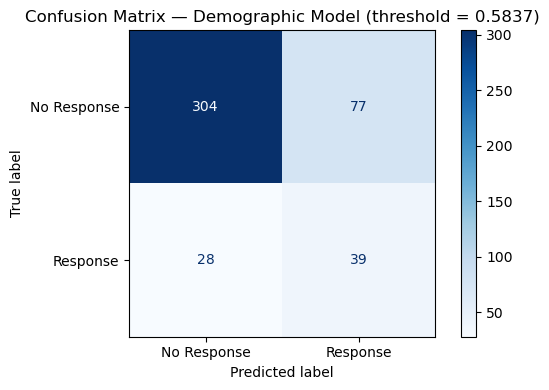

              precision    recall  f1-score   support

 No Response       0.92      0.80      0.85       381
    Response       0.34      0.58      0.43        67

    accuracy                           0.77       448
   macro avg       0.63      0.69      0.64       448
weighted avg       0.83      0.77      0.79       448



In [109]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_demo,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Demographic Model (threshold = {threshold_demo:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_demo,
                             target_names=['No Response', 'Response']))

The confusion matrix shows 39 true positives and 77 false positives. Of the 116 customers flagged by the model, only 34% are true responders meaning the company would need to contact approximately 3 customers to reach 1 true responder. 

While this is less efficient than the full model and behavioural model, it still represents a meaningful improvement over untargeted outreach where the baseline conversion rate is only 15% (approximately 6.7 contacts per responder). The 304 true negatives confirm that the model correctly excludes the majority of non-responders from the target list.

### 5.7 Precision-Recall Curve

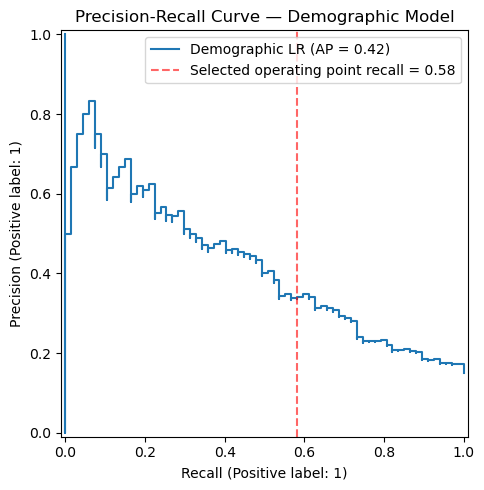

In [110]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_demo,
    name=f"Demographic LR",
    ax=ax
)

selected_recall_demo = recall_score(y_test, y_pred_demo)
ax.axvline(
    selected_recall_demo,
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Selected operating point recall = {selected_recall_demo:.2f}'
)

ax.set_title("Precision-Recall Curve — Demographic Model")
ax.legend()
plt.tight_layout()
plt.show()


At the selected operating point (recall = 0.58), the model achieves a precision of approximately 34%, reflected in the average precision of 0.42. The curve declines steeply compared to the full and behavioural models, particularly at moderate recall levels, indicating that recovering additional responders beyond 58% comes at a high cost in false positives. This reinforces that the demographic model is most effective when used for broad first-pass filtering rather than precision targeting.

### 5.8. ROC Curve


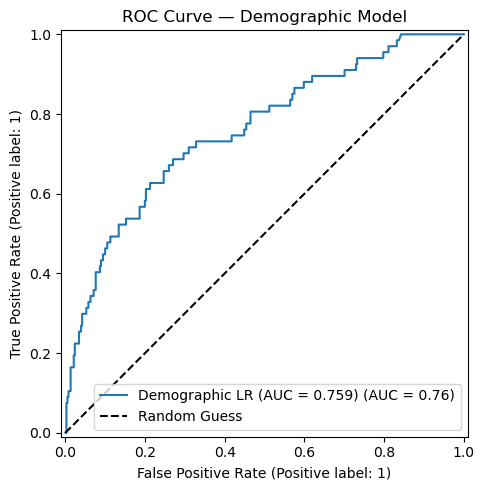

In [111]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_demo,
    name=f"Demographic LR (AUC = {roc_auc_score(y_test, y_prob_demo):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title("ROC Curve — Demographic Model")
ax.legend()
plt.tight_layout()
plt.show()

The demographic model achieves an AUC of 0.759 on the test set. While meaningfully above the 0.50 random baseline, this is noticeably below the full model (0.878) and behavioural model (0.859), confirming that demographic variables alone provide substantially weaker ranking ability.

### 5.9 Calibration

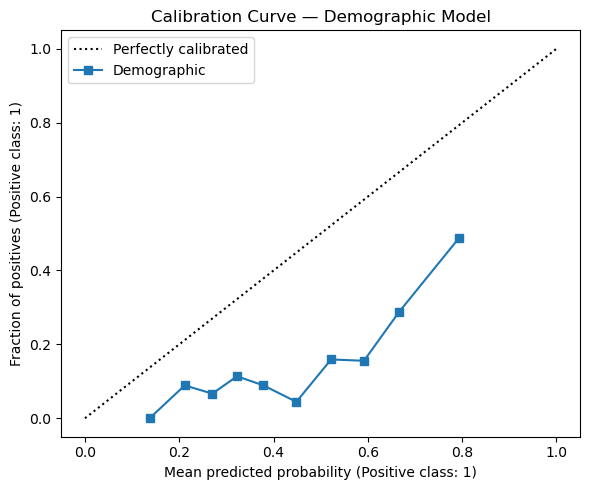

In [112]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test, y_prob_demo,
    n_bins=10,
    strategy='quantile',
    name='Demographic',
    ax=ax
)

ax.set_title("Calibration Curve — Demographic Model")
ax.legend()
plt.tight_layout()
plt.show()


The demographic model's calibration curve shows a similar pattern to the full and behavioural models — predicted probabilities are systematically below the diagonal, indicating overconfidence. However, the deviation is more pronounced at the upper end of the probability range, which is consistent with the model's tendency to assign moderate rather than high probabilities to the positive class.

This reinforces the recommendation to use the demographic model primarily as a **ranking tool** rather than a probability estimator. Its probability scores reliably identify the most likely responders in relative terms, but should not be interpreted as absolute conversion estimates without calibration.

### 5.10. Learning Curves

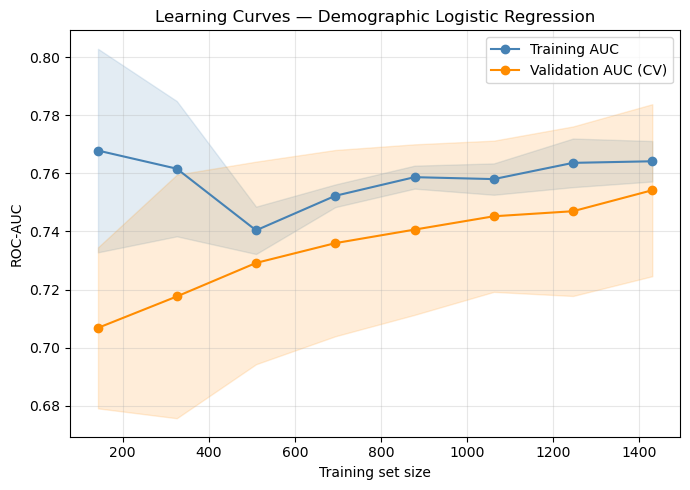

In [113]:
train_sizes, train_scores, val_scores = learning_curve(
    demo_model,
    X_train_demo,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='steelblue'
)
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color='darkorange'
)

ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Demographic Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The demographic model's learning curves show the training and validation AUC converging as training set size increases — training AUC decreases from ~0.77 to ~0.76 while validation AUC rises from ~0.71 to ~0.75, with the gap narrowing to approximately 0.01 at the full training size. This tight convergence indicates the model is well-generalising with no meaningful overfitting.

At the full training set size, validation AUC stabilises, suggesting that the model has reached its performance ceiling with the current feature set. This is consistent with the interpretation that demographic variables carry limited predictive signal for this specific campaign, and that further gains would require either richer demographic features or the reintroduction of behavioural data.

### 5.11. Feature Importance (Coefficients)


In [114]:
ohe_demo       = demo_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_demo = ohe_demo.get_feature_names_out(categorical_features_demo).tolist()
all_names_demo = numerical_features_demo + cat_names_demo

coefs_demo = demo_model.named_steps['classifier'].coef_[0]

coef_df_demo = pd.DataFrame({
    'Feature':     all_names_demo,
    'Coefficient': coefs_demo,
    'Odds Ratio':  np.exp(coefs_demo)
}).sort_values('Coefficient', ascending=False)

coef_df_demo.round(4)

,Feature,Coefficient,Odds Ratio
2,Customer_Tenure,0.6525,1.9204
8,Education_PhD,0.4413,1.5548
1,Income,0.4016,1.4942
3,Kidhome,0.0401,1.0409
0,Age,0.0000,1.0000
5,Education_Basic,0.0000,1.0000
6,Education_Graduation,0.0000,1.0000
7,Education_Master,0.0000,1.0000
10,Marital_Status_Other,0.0000,1.0000
11,Marital_Status_Single,0.0000,1.0000


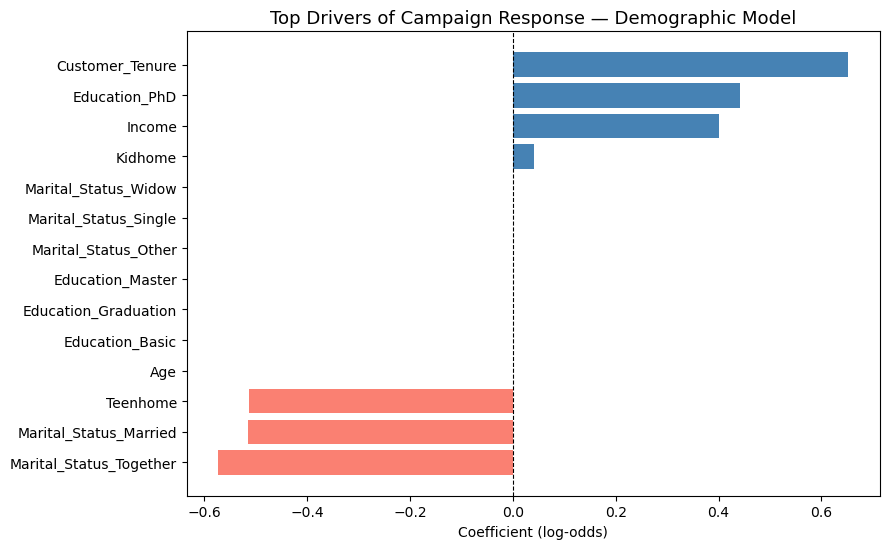

In [115]:
coef_df_demo_sorted = coef_df_demo.sort_values('Coefficient', ascending=True)
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_demo_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_demo_sorted) * 0.4)))
ax.barh(coef_df_demo_sorted['Feature'], coef_df_demo_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Demographic Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

The L1 penalty zeros out 7 of 14 features. 

Among the retained positive predictors, `Customer_Tenure` is the strongest (OR = 1.92), followed by `Education_PhD` (OR = 1.55) and `Income` (OR = 1.49), indicating that long-standing, highly educated, higher-income customers are the most responsive demographic profile. `Kidhome` has a marginal positive effect (OR = 1.04).
On the negative side, `Marital_Status_Together` (OR = 0.56), `Marital_Status_Married` (OR = 0.60), and `Teenhome` (OR = 0.60) are the strongest deterrents, confirming that customers in shared households with teenagers at home are significantly less likely to respond.

`Age`, `Education_Basic`, `Education_Graduation`, `Education_Master`, `Marital_Status_Other`, `Marital_Status_Single`, and `Marital_Status_Widow` are all zeroed out entirely by L1, confirming they add no independent predictive signal for this feature set under strong regularisation (C = 0.1).

### 5.12. Permutation Importance


Permutation Importance — Demographic Model (test set):

        Feature  Importance_Mean  Importance_Std
Customer_Tenure         0.071450        0.020255
         Income         0.068132        0.011926
       Teenhome         0.048098        0.022947
 Marital_Status         0.034154        0.008218
      Education         0.014643        0.005797
        Kidhome         0.000411        0.001253
            Age         0.000000        0.000000


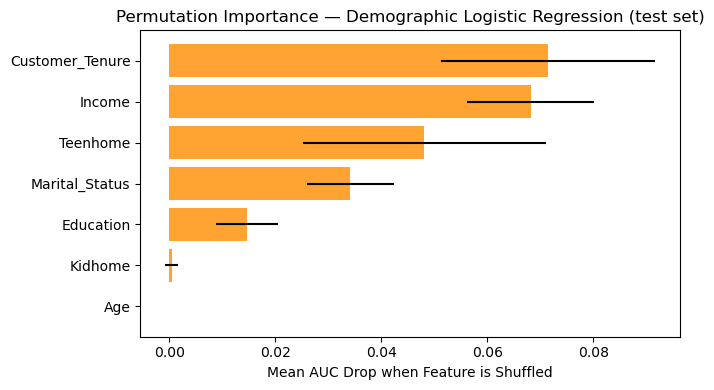

In [116]:
raw_feature_names_demo = numerical_features_demo + categorical_features_demo

perm_result_demo = permutation_importance(
    demo_model, X_test_demo, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df_demo = pd.DataFrame({
    'Feature':         raw_feature_names_demo,
    'Importance_Mean': perm_result_demo.importances_mean,
    'Importance_Std':  perm_result_demo.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Demographic Model (test set):\n")
print(perm_df_demo.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
top_perm_demo = perm_df_demo.sort_values('Importance_Mean')
ax.barh(top_perm_demo['Feature'], top_perm_demo['Importance_Mean'],
        xerr=top_perm_demo['Importance_Std'], color='darkorange', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Demographic Logistic Regression (test set)")
plt.tight_layout()
plt.show()

The permutation importance results confirm that `Income` and `Customer_Tenure` are the dominant demographic predictors — shuffling either produces the largest drop in AUC. The categorical variables (`Education`, `Marital_Status`) contribute measurable but smaller effects, and `Age` shows near-zero importance, consistent with its near-zero coefficient in the feature importance table.

The relatively flat importance profile — where no single variable dominates as strongly as `Total_Accepted_Campaigns` does in the behavioural model — reflects the nature of demographic data: no single demographic characteristic is a strong individual predictor of campaign response, but the combination of several weak signals produces a usable model.

### 5.13. SHAP Values

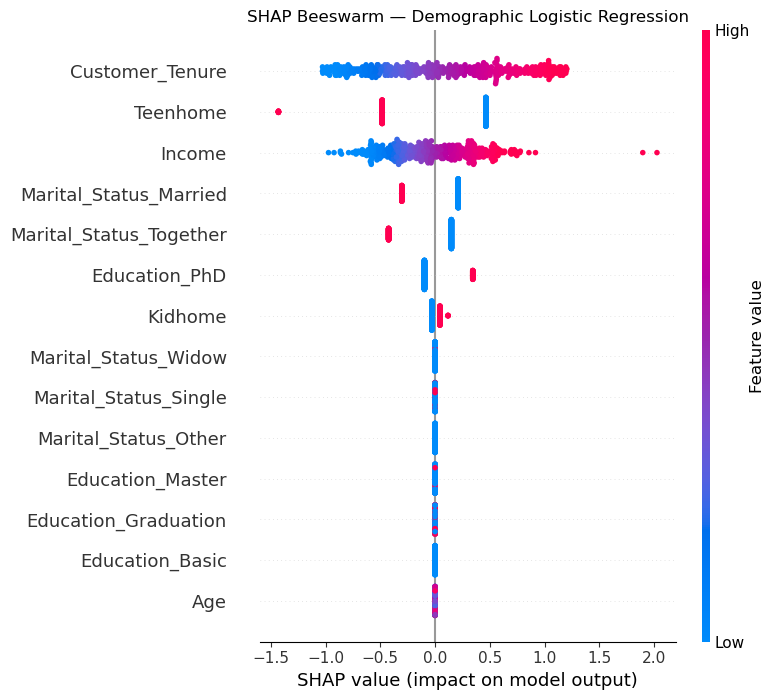

In [117]:
X_demo_test_t  = demo_model.named_steps['preprocessor'].transform(X_test_demo)
X_demo_train_t = demo_model.named_steps['preprocessor'].transform(X_train_demo)

explainer_demo   = shap.LinearExplainer(
    demo_model.named_steps['classifier'],
    X_demo_train_t,
    feature_perturbation='interventional'
)
shap_values_demo = explainer_demo.shap_values(X_demo_test_t)

shap.summary_plot(shap_values_demo, X_demo_test_t,
                  feature_names=all_names_demo, show=False)
plt.title("SHAP Beeswarm — Demographic Logistic Regression")
plt.tight_layout()
plt.show()

The SHAP beeswarm for the demographic model shows a distinctly different pattern from the full and behavioural models. Rather than one or two features with clearly dominant positive SHAP values, the demographic model distributes its positive signal across several variables — `Customer_Tenure`, `Income`, `Education_PhD` all contribute meaningfully for customers at the upper end of their distributions.

The negative side is more concentrated: `Marital_Status_Together` and `Marital_Status_Married` produce the largest negative SHAP values, confirming that cohabiting status is the single most consistent negative signal in the demographic model, and `Teenhome` shows a similarly clear leftward cluster. This is worth noting for segmentation purposes — shared-household status is a clean, observable variable that can be used as a simple exclusion filter even without running the full model scoring pipeline.

### 5.14. Interpretation of Demographic and Household Model Results

The demographic model achieves a **ROC-AUC** of 0.76, indicating moderate discriminative ability, consistent with the EDA finding that demographic variables are inherently weaker predictors of campaign response than behavioural ones. The F1-optimal threshold was found at 0.5837 through out-of-fold cross-validation, reflecting the model's limited confidence in assigning high probabilities to the minority class.

At this threshold, the model correctly identifies 39 out of 67 actual responders, achieving a **recall** of 58% on the positive class. **Precision** stands at 34%, meaning that out of 116 customers flagged as likely responders, roughly 1 in 3 would actually convert. In practical terms, the company would need to contact approximately 3 customers to reach 1 true responder, still a meaningful improvement over untargeted outreach where the baseline conversion rate is only 15%.

The L1 penalty zeros out 7 of 14 features, retaining a sparse and interpretable model. Among the retained positive predictors, the coefficient table confirms the demographic profile of a likely responder: `Customer_Tenure` (OR = 1.92) and `Education_PhD` (OR = 1.55) are the strongest positive predictors, indicating that long-standing, highly educated, higher-income customers are the most responsive demographic profile. 

On the negative side, `Marital_Status_Together` (OR = 0.56) and `Marital_Status_Married` (OR = 0.60) are the strongest deterrents, followed by `Teenhome` (OR = 0.60), suggesting that customers in shared households with lower education and teenagers at home are significantly less receptive. 

Age, all education levels except PhD, and most marital status categories were zeroed out entirely by L1, confirming they add no meaningful independent signal.

Overall, the demographic model is best understood as a profiling tool rather than a precision targeting instrument.  Its moderate recall makes it useful for broad identification of likely responders when transaction history is unavailable, but its low precision means it generates a substantial number of wasted contacts. It is most appropriately used as a fallback for newly acquired customers without purchase history, where the behavioural and full models cannot be applied.

## 6. Summary of Results

### 6.1. Metrics Table

In [128]:
full_eval = evaluate_model(full_model, X_test_full, y_test, "Full", threshold_full)
behav_eval = evaluate_model(behav_model, X_test_behav, y_test, "Behavioural", threshold_behav)
demo_eval = evaluate_model(demo_model, X_test_demo, y_test, "Demographic", threshold_demo)

results_df = pd.DataFrame([full_eval, behav_eval, demo_eval]).set_index('Model')

metric_cols = ['ROC-AUC', 'Precision', 'Recall', 'F1', 'Accuracy']

def highlight_best(col):
    if col.name not in metric_cols:
        return ['' for _ in col]
    max_val = col.max()
    return [
        'background-color: #a8d5a2; color: #155724; font-weight: bold'
        if v == max_val else ''
        for v in col
    ]

results_df.style.apply(highlight_best, axis=0).format("{:.4f}")


,Threshold,ROC-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Full,0.5928,0.8784,0.4800,0.7164,0.5749,0.8415
Behavioural,0.6148,0.8588,0.5000,0.5224,0.5109,0.8504
Demographic,0.5837,0.7594,0.3362,0.5821,0.4262,0.7656


### 6.2. ROC Curves

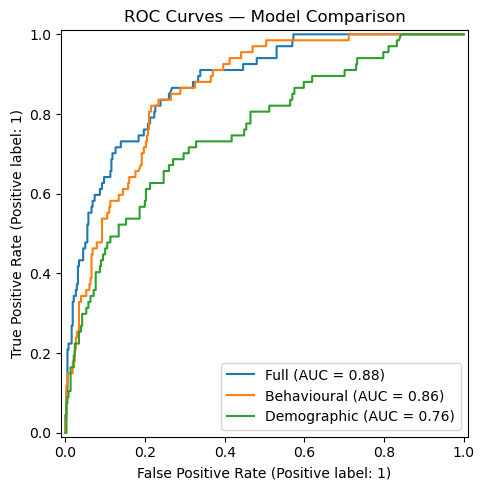

In [129]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_full, name="Full", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_behav, name="Behavioural", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_demo, name="Demographic", ax=ax)
ax.set_title("ROC Curves — Model Comparison")
plt.tight_layout()
plt.show()

### 6.3 Calibration

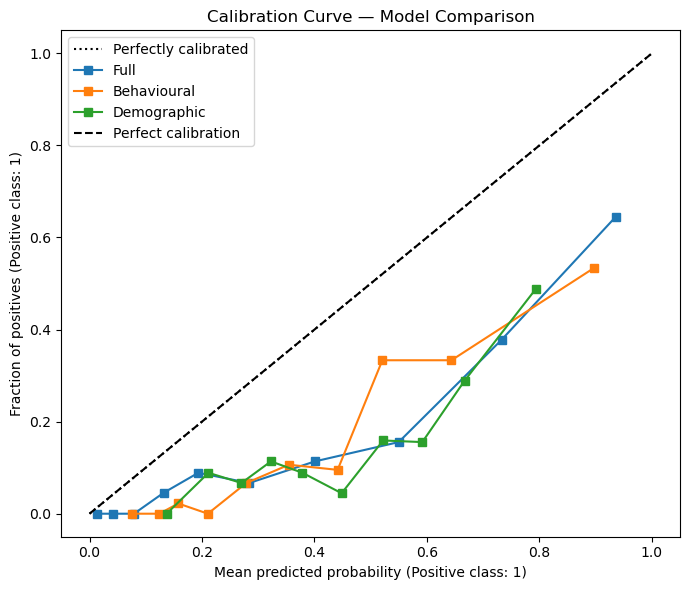

In [130]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(7, 6))

CalibrationDisplay.from_predictions(
    y_test, y_prob_full,
    n_bins=10,
    strategy='quantile',
    name='Full',
    ax=ax
)

CalibrationDisplay.from_predictions(
    y_test, y_prob_behav,
    n_bins=10,
    strategy='quantile',
    name='Behavioural',
    ax=ax
)

CalibrationDisplay.from_predictions(
    y_test, y_prob_demo,
    n_bins=10,
    strategy='quantile',
    name='Demographic',
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_title("Calibration Curve — Model Comparison")
ax.set_xlabel("Mean predicted probability (Positive class: 1)")
ax.set_ylabel("Fraction of positives (Positive class: 1)")
ax.legend()
plt.tight_layout()
plt.show()


### 6.4. Top-20% Lift Analysis

Because the business objective is targeted outreach rather than uniform classification, model performance can also be evaluated in terms of **ranking quality**, specifically, how efficiently each model concentrates actual responders within the highest-priority customer segments.

The top-20% lift analysis addresses a practical campaign planning question: *if we could only contact 20% of our customer base, how many of the true responders would we capture, and how does that compare to selecting 20% at random?*

This provides a more operational view of model value than aggregate metrics like AUC or F1, as it directly quantifies the improvement in campaign return from using the model versus untargeted outreach.

The table reports the following metrics for each model's top-20% ranked segment:

| Metric | Definition |
|---|---|
| **Responders in Segment** | Actual responders found within the top 20% highest-scored customers |
| **Response Rate in Segment** | Conversion rate within that top 20% |
| **Baseline Response Rate** | Overall response rate in the full test set (~15%) |
| **Capture Rate** | Share of all true responders captured within the top 20% |
| **Lift** | How many times better the top 20% performs compared to random selection |

A lift of 2.0, for example, means the top segment generates twice as many conversions per contact as a randomly selected group of the same size.

In [131]:
def top_k_lift_table(y_true, y_prob, model_name, top_frac=0.20):
    eval_df = pd.DataFrame({
        'y_true': y_true.reset_index(drop=True),
        'y_prob': y_prob
    }).sort_values('y_prob', ascending=False).reset_index(drop=True)

    n_total = len(eval_df)
    n_top = int(np.ceil(n_total * top_frac))

    top_df = eval_df.iloc[:n_top]

    baseline_rate = eval_df['y_true'].mean()
    top_rate = top_df['y_true'].mean()

    responders_total = eval_df['y_true'].sum()
    responders_top = top_df['y_true'].sum()

    capture_rate = responders_top / responders_total if responders_total > 0 else np.nan
    lift = top_rate / baseline_rate if baseline_rate > 0 else np.nan

    return {
        'Model': model_name,
        'Top Segment': f'Top {int(top_frac * 100)}%',
        'Customers in Segment': n_top,
        'Total Customers': n_total,
        'Responders in Segment': int(responders_top),
        'Total Responders': int(responders_total),
        'Response Rate in Segment': top_rate,
        'Baseline Response Rate': baseline_rate,
        'Capture Rate': capture_rate,
        'Lift': lift
    }


lift_full = top_k_lift_table(y_test, y_prob_full, 'Full', top_frac=0.20)
lift_behav = top_k_lift_table(y_test, y_prob_behav, 'Behavioural', top_frac=0.20)
lift_demo = top_k_lift_table(y_test, y_prob_demo, 'Demographic', top_frac=0.20)

lift_df = pd.DataFrame([lift_full, lift_behav, lift_demo]).set_index('Model')

highlight_cols = ['Response Rate in Segment', 'Capture Rate', 'Lift']

def highlight_best(col):
    if col.name not in highlight_cols:
        return ['' for _ in col]
    max_val = col.max()
    return [
        'background-color: #a8d5a2; color: #155724; font-weight: bold'
        if v == max_val else ''
        for v in col
    ]

lift_df.style.apply(highlight_best, axis=0).format({
    'Response Rate in Segment': '{:.2%}',
    'Baseline Response Rate': '{:.2%}',
    'Capture Rate': '{:.2%}',
    'Lift': '{:.2f}'
})


,Top Segment,Customers in Segment,Total Customers,Responders in Segment,Total Responders,Response Rate in Segment,Baseline Response Rate,Capture Rate,Lift
Model,,,,,,,,,
Full,Top 20%,90,448,46,67,51.11%,14.96%,68.66%,3.42
Behavioural,Top 20%,90,448,39,67,43.33%,14.96%,58.21%,2.90
Demographic,Top 20%,90,448,35,67,38.89%,14.96%,52.24%,2.60


### 6.5. Recommended Model

Based on the results across all three models, the **Full Model** is the recommended specification for deployment and for cross-model comparison in the advanced modelling stage.

**Performance summary:**

| Model | ROC-AUC | Precision | Recall | F1 | Lift (top 20%) |
|---|---|---|---|---|---|
| **Full** | **0.88** | 0.48 | **0.72** | **0.58** | **~3.4×** |
| Behavioural | 0.86 | **0.50** | 0.52 | 0.51 | ~2.9× |
| Demographic | 0.76 | 0.34 | 0.58 | 0.43 | ~2.6× |

**Why the Full Model:**

The full model achieves the highest ROC-AUC (0.878), F1 (0.575), recall (72%), and lift (3.42×) of the three specifications. More importantly, it uses the complete engineered feature set — combining behavioural signals with demographic and household variables — which provides the richest possible representation of each customer for the classifier to work with.

Consistency with the advanced modelling stage is also a key consideration. The Random Forest and other ensemble models developed in the subsequent notebook are trained on the same full feature set. Using the full logistic regression as the baseline ensures that cross-model comparisons are valid: differences in performance between models reflect differences in algorithm and capacity, not differences in input information.

**Why not the Behavioural Model as primary:**

The behavioural model is remarkably competitive — it achieves an AUC only 2 percentage points below the full model using six features rather than thirteen, and delivers a lift of 2.90×. This is a useful finding in its own right: it confirms that behavioural history dominates the predictive signal. However, for a head-to-head comparison against tree-based and ensemble methods, the full feature set is the appropriate input, as it gives every model the same informational starting point.

**Role of the Behavioural and Demographic Models:**

The three-model comparison in this notebook serves a diagnostic purpose: it isolates the contribution of each feature group and confirms that behavioural variables drive most of the predictive signal, with demographics adding a secondary but meaningful layer. This justifies retaining all features in the full model rather than discarding the demographic variables.

- The **Behavioural Model** is the recommended fallback when demographic data is unavailable or when a simpler, more interpretable targeting rule is needed.
- The **Demographic Model** is the recommended tool for profiling new customers or prospects who lack purchase history, where its high recall (58%) is more valuable than its low precision.

**Deployment note:**

All three models are miscalibrated — predicted probabilities underestimate actual conversion rates. Before using probability scores for budget allocation or ROI estimation, Platt scaling or isotonic regression calibration should be applied. For ranking-based targeting (selecting the top N customers by score), calibration is not required.

## 7. Business Recommendations

The modelling results converge on a consistent picture: campaign response is primarily driven by **past engagement and spending behaviour**, with demographic factors playing a secondary but meaningful role. The following recommendations translate these findings into actionable targeting and campaign design decisions.

### 7.1. Primary Targeting Strategy — Behavioural Scoring

Deploy the behavioural model to score the active customer base before each campaign cycle. Prioritise customers who:

- Have accepted at least one previous campaign (`Total_Accepted_Campaigns > 0`)
- Have purchased within the last 30 days (low `Recency`)
- Concentrate their spending in fewer, higher-value transactions (high `Total_Spending`, moderate `Total_Purchases`)

These three conditions identify the core of the addressable audience — customers whose engagement history already signals receptiveness. In the test set, focusing outreach on the top-scored 20% of customers captures 2.90× more responders per contact than random selection, while reducing the number of wasted contacts.

### 7.2. Customer Segments to Prioritise

The coefficient and SHAP analyses identify two high-value segments that should be prioritised in campaign targeting:

**Segment A — Engaged long-tenure customers**: Customers with high `Customer_Tenure`, high `Total_Accepted_Campaigns`, and high spending levels. These customers are already committed to the brand and have demonstrated willingness to respond to direct marketing. The full model identifies this group through a combination of `Customer_Tenure` (OR = 2.61), `Total_Accepted_Campaigns` (OR = 2.94), and education-level indicators.

**Segment B — High-spend, low-frequency buyers**: Customers with high `Total_Spending` but moderate `Total_Purchases` — those who buy less often but spend more per transaction. The negative coefficient on `Total_Purchases` alongside a positive coefficient on `Total_Spending` points to a distinct sub-segment of premium buyers who are responsive to subscription-style offers that consolidate purchasing.

### 7.3. Segments to Deprioritise

The following customer profiles consistently show low response probability across all three models and should be deprioritised or excluded from campaign targeting to reduce wasted spend:

- **Customers in couple households** (`Marital_Status_Married`, `Marital_Status_Together`): Response probability is significantly lower for customers in shared households, possibly due to joint purchase decision-making or lower discretionary spend on premium food products.
- **Customers with teenagers at home** (`Teenhome` OR = 0.60 in the demographic model): Household budget constraints or different purchase priorities may reduce responsiveness to premium subscription campaigns.
- **Inactive customers** (high `Recency`): Customers who have not engaged with the brand in the last 60–90 days show markedly lower response probability. These customers may be better served by a reactivation campaign before being included in the subscription campaign funnel.


### 7.4. Campaign Timing

`Recency` is the most consistently negative predictor across all three models, confirming that campaign timing relative to recent purchase activity matters. The company should aim to reach customers **within 30 days of their most recent purchase**, when engagement is highest. Sending campaign communications to customers who last purchased more than 60 days ago is unlikely to be effective without a prior reactivation touchpoint.

### 7.5. When Demographic Data Is the Only Input

For newly acquired customers or prospects without purchase history, the demographic model provides a useful first-pass filter. Based on its coefficients, the profile most likely to respond is:

- Long-standing customer relationship (`Customer_Tenure` OR = 1.92)
- Higher education level, particularly postgraduate (`Education_PhD` OR = 1.55)
- Higher income (`Income` OR = 1.49)
- Living alone or widowed (negative coefficients for married and cohabiting statuses)
- No teenagers in the household (`Teenhome` OR = 0.60)

This profile can inform prospect acquisition and segmentation decisions when behavioural data is not yet available.



### 7.6. Model Monitoring and Refresh

The models were trained on historical campaign data and assume that the behavioural patterns identified remain stable over time. The following monitoring practices are recommended:

- **Track precision and recall monthly** on the most recent campaign wave. A sustained drop in precision (more wasted contacts) or recall (fewer conversions) signals that the model may need retraining on more recent data.
- **Monitor `Total_Accepted_Campaigns` distribution**: as more campaigns are run, this variable's distribution will shift. If most customers accumulate high acceptance counts, the variable's discriminatory power will diminish and the model should be retrained.
- **Retrain annually** at a minimum, or after any major change in campaign format, pricing, or product offering, as these changes will affect the relationship between features and response.